# Model fitting and parameter estimation using the full dataset

In [ ]:
import arviz as az
import scipy.stats as stats
from scipy.integrate import solve_ivp
import seaborn as sns
import pickle as pkl
import pandas as pd
import numpy as np
# python font no dingbattes
import matplotlib
from matplotlib import font_manager
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

import os
helvetica_font_path = None  # set this to a real Helvetica .ttf/.otf file if you have one
if helvetica_font_path and os.path.exists(helvetica_font_path):
    font_manager.fontManager.addfont(helvetica_font_path)
    matplotlib.rcParams["font.family"] = "sans-serif"
    matplotlib.rcParams["font.sans-serif"] = ["Helvetica"]
else:
    matplotlib.rcParams["font.family"] = "sans-serif"
    matplotlib.rcParams["font.sans-serif"] = ["Nimbus Sans", "DejaVu Sans"]
    print("Helvetica font file not set; using installed fallback font.")
    
# global font size
sns.set_context("notebook", font_scale=1.3)

In [2]:
#Change the working directory
import os
os.chdir('/home/apoorva/Desktop/MZB-new-analysis')

In [3]:
# Compatibility shim for pickles created with NumPy 2.x
import sys
import numpy.core as _np_core

sys.modules.setdefault('numpy._core', _np_core)
sys.modules.setdefault('numpy._core.multiarray', _np_core.multiarray)
sys.modules.setdefault('numpy._core.numeric', _np_core.numeric)
sys.modules.setdefault('numpy._core.umath', _np_core.umath)
sys.modules.setdefault('numpy._core._multiarray_umath', _np_core._multiarray_umath)

<module 'numpy.core._multiarray_umath' from '/home/apoorva/Desktop/MZB-new-analysis/.venv-1/lib/python3.8/site-packages/numpy/core/_multiarray_umath.cpython-38-x86_64-linux-gnu.so'>

In [4]:
#open the output file
file_path = 'data/New output (pkl)/Steady State/Unified_model/T2_varyinflux_divisiondensity_infprior.pkl'
with open(file_path, 'rb') as f:
    unified_T2 = pkl.load(f)
    
file_path = 'data/New output (pkl)/Steady State/Unified_model/T1_varyinflux_divisiondensity_infprior.pkl'
with open(file_path, 'rb') as f:
    unified_T1 = pkl.load(f)
    
unified_df_T1 = unified_T1.draws_pd()

unified_df_T2 = unified_T2.draws_pd()
    
    
file_path = 'data/New output (pkl)/Steady State/SHM/SHM_T2.pkl'
with open(file_path, 'rb') as f:
    SHM_df_T2 = pkl.load(f)
    
file_path = 'data/New output (pkl)/Steady State/SHM/SHM_T1.pkl'
with open(file_path, 'rb') as f:
    SHM_df_T1 = pkl.load(f)


/home/apoorva/Desktop/MZB-new-analysis/.venv-1/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# open experimental data file 
df_adult = pd.read_csv('data/New_data/new_data_MZB.csv')
df_adult = df_adult.sort_values(by='Age at S1K')
df_adult.loc[1, 'Age at BMT'] = 74
#Add one column in df_Ki67 and df_Nfd for grouping the data based on age at bmt
df_adult['agebin'] = pd.cut(df_adult['Age at BMT'], bins=[0,70, 140], labels=['<10 weeks', '>10 weeks'])


df_ont = pd.read_csv('data/Ontogeny_T1.csv')
df_ont_T2 = pd.read_excel('data/New_data/20190412_MV_Bcellnumbers_ontogeny.xlsx', sheet_name='SPLEEN_Cell number')

print(df_ont.head())

   age.at.S1K  total_T1_AA4.1+       total_MZ
0          11     4.145272e+06   12058.666667
1          11     3.223400e+06    7450.000000
2          11     3.302817e+06   18873.238938
3          11     2.677656e+06   11941.171604
4          14     6.970682e+06  173580.615385


In [6]:
#Functions for precursor dynamics of T1 and T2 and division rate
def P2(t):
    theta_0 = np.exp(14.08)
    nu = 0.25
    n = 1.8
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))

def P1(t):
    theta_0 = np.exp(14.10)
    nu = 0.31
    n = 2
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))
 
def b_m(M, b, K):
    return b * (1 - (M / K))

# Define the ODE function
# Initial conditions at time t=40
M0 = [12058]

In [7]:
# Define the splines for donor fraction and Ki67 fraction in T2 precursors
def chi_source2(time, chi_est=0.85, nu=0.1, t0=10):
    if (time - t0) < 0:
        return 0.0
    else:
        return chi_est * (1 - np.exp(-nu * (time - t0)))
    
def eps_donor2(time, m=-3.79e-5, c=0.99, t0=40):
    if (time - t0) < 0:
        return 0.0
    else:
        return m * (time - t0) + c
    
def eps_host2(time, m=-1.7e-4, c=0.98, t0=40):
    if (time - t0) < 0:
         return 0.0
    else:
        return m * (time - t0) + c
    
def q(time, phi, phi0, r):
    return ((phi - phi0)/ (1 +(r/time)**7)) + phi0

In [8]:
# Define the splines for donor fraction and Ki67 fraction in T1 precursors
def chi_source1(time, chi_est=0.83, nu=0.08, t0=10):
    if (time - t0) < 0:
        return 0.0
    else:
        return chi_est * (1 - np.exp(-nu * (time - t0)))
    
def eps_donor1(time, m=-1.9e-4, c=0.97, t0=40):
    if (time - t0) < 0:
        return 0.0
    else:
        return m * (time - t0) + c
    
def eps_host1(time, m=-3.8e-5, c=0.88, t0=40):
    if (time - t0) < 0:
         return 0.0
    else:
        return m * (time - t0) + c

def q(time, phi, phi0, r):
    return ((phi - phi0)/ (1 +(r/time)**7)) + phi0

In [9]:
# solve exponential ode using posterior samples
y_pred_samples_T1 = []

time_points_counts = np.linspace(11, 750, 750)
model_params_T1 = (unified_df_T1['b'], unified_df_T1['d'], unified_df_T1['K'], unified_df_T1['phi'], unified_df_T1['phi0'], unified_df_T1['r'])

for i in range(len(unified_df_T1)):
    phi1 = unified_df_T1['phi'][i]
    phi01 = unified_df_T1['phi0'][i]
    r1 = unified_df_T1['r'][i]
    b1 = unified_df_T1['b'][i]
    d1 = unified_df_T1['d'][i]
    k1 = unified_df_T1['K'][i]

    
    def model_ode1(t, M, phi, phi0, r, b, d, K):
        dMdt = q(t, phi, phi0, r)*P1(t) + b_m(M, b, K) * M - d * M
        return np.array(dMdt)
    y0_val = [12058]
    y_pred1 = solve_ivp(model_ode1, [11, 750], y0_val, t_eval=time_points_counts, args=(phi1, phi01, r1, b1, d1, k1))
    y_pred_samples_T1.append(y_pred1.y[0])



In [10]:
# solve exponential ode using posterior samples
y_pred_samples_T2 = []

time_points_counts = np.linspace(11, 750, 750)
model_params_T2 = (unified_df_T2['b'], unified_df_T2['d'], unified_df_T2['K'], unified_df_T2['phi'], unified_df_T2['phi0'], unified_df_T2['r'])

for i in range(len(unified_df_T2)):
    phi = unified_df_T2['phi'][i]
    phi0 = unified_df_T2['phi0'][i]
    r = unified_df_T2['r'][i]
    b = unified_df_T2['b'][i]
    d = unified_df_T2['d'][i]
    k = unified_df_T2['K'][i]

    
    def model_ode2(t, M, phi, phi0, r, b, d, K):
        dMdt = q(t, phi, phi0, r)*P2(t) + b_m(M, b, K) * M - d * M
        return np.array(dMdt)
    y0_val = [12058]
    y_pred2 = solve_ivp(model_ode2, [11, 750], y0_val, t_eval=time_points_counts, args=(phi, phi0, r, b, d, k))
    y_pred_samples_T2.append(y_pred2.y[0])



In [11]:
def ode_sys_unified_T1(time, X, phi, phi0, r, b, d, k, ageATBMT):
    """
    ODE system for unified model
    
    Parameters:
    -----------
    time : float
        Current time point
    X : array-like
        State vector [donor Ki67+, donor Ki67-, host Ki67+, host Ki67-]
    parms : array-like
        Parameters [r, rho, delta, M_stable, k, ageATBMT]

    Returns:
    --------
    dXdt : numpy array
        Derivatives of state variables
    """
    
    # Fixed parameters
    P1 = 1298783
    beta = 3.5
    
    
    # Total cell count
    M_total = X[0] + X[1] + X[2] + X[3]
    
    # Calculate density-dependent division rate
    rho_dens = b_m(M_total, b, k)
    
    # Initialize derivatives
    dXdt = np.zeros(4)
    
    # Donor Ki67+ cells
    dXdt[0] = (q(time, phi, phi0, r) * eps_donor1(time) * chi_source1(time - ageATBMT)*P1 + 
               rho_dens * (X[0] + 2 * X[1]) - ((1 / beta) + d) * X[0])
    
    # Donor Ki67- cells
    dXdt[1] = (q(time, phi, phi0, r) * (1 - eps_donor1(time)) * chi_source1(time - ageATBMT)*P1 + 
               (1 / beta) * X[0] - (rho_dens + d) * X[1])
    
    # Host Ki67+ cells
    dXdt[2] = (q(time, phi, phi0, r) * eps_host1(time) * (1 - chi_source1(time - ageATBMT))*P1 + 
               rho_dens * (X[2] + 2 * X[3]) - ((1 / beta) + d) * X[2])
    
    # Host Ki67- cells
    dXdt[3] = (q(time, phi, phi0, r) * (1 - eps_host1(time)) * (1 - chi_source1(time - ageATBMT))*P1 + 
               (1 / beta) * X[2] - (rho_dens + d) * X[3])
    
    return dXdt

In [12]:
def ode_sys_unified_T2(time, X, phi, phi0, r, b, d, k, ageATBMT):
    """
    ODE system for unified model
    
    Parameters:
    -----------
    time : float
        Current time point
    X : array-like
        State vector [donor Ki67+, donor Ki67-, host Ki67+, host Ki67-]
    parms : array-like
        Parameters [r, rho, delta, M_stable, k, ageATBMT]

    Returns:
    --------
    dXdt : numpy array
        Derivatives of state variables
    """
    
    # Fixed parameters
    P2 = 1308516
    beta = 3.5
    
    
    # Total cell count
    M_total = X[0] + X[1] + X[2] + X[3]
    
    # Calculate density-dependent division rate
    rho_dens = b_m(M_total, b, k)
    
    # Initialize derivatives
    dXdt = np.zeros(4)
    
    # Donor Ki67+ cells
    dXdt[0] = (q(time, phi, phi0, r) * eps_donor1(time) * chi_source1(time - ageATBMT)*P2 + 
               rho_dens * (X[0] + 2 * X[1]) - ((1 / beta) + d) * X[0])
    
    # Donor Ki67- cells
    dXdt[1] = (q(time, phi, phi0, r) * (1 - eps_donor1(time)) * chi_source1(time - ageATBMT)*P2 + 
               (1 / beta) * X[0] - (rho_dens + d) * X[1])
    
    # Host Ki67+ cells
    dXdt[2] = (q(time, phi, phi0, r) * eps_host1(time) * (1 - chi_source1(time - ageATBMT))*P2 + 
               rho_dens * (X[2] + 2 * X[3]) - ((1 / beta) + d) * X[2])
    
    # Host Ki67- cells
    dXdt[3] = (q(time, phi, phi0, r) * (1 - eps_host1(time)) * (1 - chi_source1(time - ageATBMT))*P2 + 
               (1 / beta) * X[2] - (rho_dens + d) * X[3])
    
    return dXdt

In [13]:
# estimated parameters 
phi1 = unified_T1.stan_variable('phi') # influx rate
phi01 = unified_T1.stan_variable('phi0') # baseline influx rate
r1 = unified_T1.stan_variable('r') # r
b1 = unified_T1.stan_variable('b') # division rate
d1 = unified_T1.stan_variable('d') # death rate
k1 = unified_T1.stan_variable('K') # carrying capacity

phi2 = unified_T2.stan_variable('phi') # influx rate
phi02 = unified_T2.stan_variable('phi0') # baseline influx rate
r2 = unified_T2.stan_variable('r') # r
b2 = unified_T2.stan_variable('b') # division rate
d2 = unified_T2.stan_variable('d') # death rate
k2 = unified_T2.stan_variable('K') # carrying capacity



In [14]:
# write a function to solve the ODEs and return the results as a df
def solve_ode_system(phi1, phi01, r1, b1, d1, k1, age_at_bmt, solve_time_start, oupt):
    """Solve the ODE system for given parameters and return results as a DataFrame."""

    y0 = solve_ivp(model_ode1, [11, 40], M0, t_eval=[40], args=(phi1, phi01, r1, b1, d1, k1))
    kappa0 = 0.16
    host_ki67_plus = np.mean(kappa0*y0.y[:, -1])
    host_ki67_minus = np.mean((1-kappa0)*y0.y[:, -1])
    # Initial conditions at t=40
    initial_cond_t40 = np.array([0, 0, host_ki67_plus, host_ki67_minus])  # [donor_ki67+, donor_ki67-, host_ki67+, host_ki67-]

    # Use mean values for rho and delta for ODE solving
    phi_mean = np.mean(phi1)
    phi0_mean = np.mean(phi01)
    r_mean = np.mean(r1)
    b_mean = np.mean(b1)
    d_mean = np.mean(d1)
    k_mean = np.mean(k1)
    
    ic_solution = solve_ivp(
        ode_sys_unified_T1, (40, age_at_bmt), initial_cond_t40, args=(phi_mean, phi0_mean, r_mean, b_mean, d_mean, k_mean, age_at_bmt)
    )
    initial_at_bmt = ic_solution.y[:, -1]

    # t_span = (age_at_bmt, 750)
    t_eval = np.arange(solve_time_start, 750, 1)
    
    # Solve the ODEs
    sol = solve_ivp(ode_sys_unified_T1, t_span=[11,750], y0=initial_at_bmt, args=(phi_mean, phi0_mean, r_mean, b_mean, d_mean, k_mean, age_at_bmt), t_eval=t_eval, method='RK45')

    # calculate chimerism in the source
    chi_values = np.array([chi_source1(t - age_at_bmt) for t in sol.t])
    
    # Create a DataFrame from the solution
    df_results = pd.DataFrame(sol.y.T, columns=['Donor_Ki67+', 'Donor_Ki67-', 'Host_Ki67+', 'Host_Ki67-'])
    # calculate total MZ cells and Nfd
    df_results['Total_MZ'] = df_results['Donor_Ki67+'] + df_results['Donor_Ki67-'] + df_results['Host_Ki67+'] + df_results['Host_Ki67-']
    df_results['chi_source'] = chi_values
    df_results['Nfd'] = (df_results['Donor_Ki67+'] + df_results['Donor_Ki67-']) / (df_results['Total_MZ'] * df_results['chi_source'])
    # calculate fractions of Ki67+ cells in donor and host
    df_results['Frac_Ki67+_Donor'] = df_results['Donor_Ki67+'] / (df_results['Donor_Ki67+'] + df_results['Donor_Ki67-']) 
    df_results['Frac_Ki67+_Host'] = df_results['Host_Ki67+'] / (df_results['Host_Ki67+'] + df_results['Host_Ki67-']) 

    if oupt == 'counts':
        return df_results[['Total_MZ']]
    elif oupt == 'Nfd':
        return df_results[['Nfd']]
    elif oupt == 'ki67':
        return df_results[['Frac_Ki67+_Donor', 'Frac_Ki67+_Host']]



def get_ode_summary(phi1, phi01, r1, b1, d1, k1, age_at_bmt, solve_time_start, n_samples, oupt):
    """
    Solve the ODE system for n_samples parameter sets and return summary statistics as a DataFrame.
    """
    host_age = np.arange(solve_time_start, 750, 1)
    n_time = host_age.size

    if oupt == 'ki67':
        donor_samples = np.empty((n_time, n_samples), dtype=float)
        host_samples = np.empty((n_time, n_samples), dtype=float)

        for i in range(n_samples):
            df_sol = solve_ode_system(
                phi1[i], phi01[i], r1[i], b1[i], d1[i], k1[i], age_at_bmt,
                solve_time_start=solve_time_start,
                oupt=oupt
            )
            donor_samples[:, i] = df_sol['Frac_Ki67+_Donor'].to_numpy()
            host_samples[:, i] = df_sol['Frac_Ki67+_Host'].to_numpy()

        df_summary_donor = pd.DataFrame({
            'mean_pred': np.median(donor_samples, axis=1),
            'lb': np.quantile(donor_samples, 0.025, axis=1),
            'ub': np.quantile(donor_samples, 0.975, axis=1),
            'Host_Age': host_age,
            'Type': 'Donor'
        })
        df_summary_host = pd.DataFrame({
            'mean_pred': np.median(host_samples, axis=1),
            'lb': np.quantile(host_samples, 0.025, axis=1),
            'ub': np.quantile(host_samples, 0.975, axis=1),
            'Host_Age': host_age,
            'Type': 'Host'
        })
        df_summary = pd.concat([df_summary_donor, df_summary_host], axis=0)

    else:
        if oupt == 'counts':
            value_col = 'Total_MZ'
        elif oupt == 'Nfd':
            value_col = 'Nfd'
        else:
            raise ValueError(f"Unsupported output type: {oupt}")

        output_samples = np.empty((n_time, n_samples), dtype=float)
        for i in range(n_samples):
            df_sol = solve_ode_system(
                phi1[i], phi01[i], r1[i], b1[i], d1[i], k1[i], age_at_bmt,
                solve_time_start=solve_time_start,
                oupt=oupt
            )
            output_samples[:, i] = df_sol[value_col].to_numpy()

        df_summary = pd.DataFrame({
            'mean_pred': np.median(output_samples, axis=1),
            'lb': np.quantile(output_samples, 0.025, axis=1),
            'ub': np.quantile(output_samples, 0.975, axis=1),
            'Host_Age': host_age
        })

    return df_summary

In [15]:
# write a function to solve the ODEs and return the results as a df
def solve_ode_system_T2(phi2, phi02, r2, b2, d2, k2, age_at_bmt, solve_time_start, oupt):
    """Solve the ODE system for given parameters and return results as a DataFrame."""

    y0 = solve_ivp(model_ode2, [11, 40], M0, t_eval=[40], args=(phi2, phi02, r2, b2, d2, k2))
    kappa0 = 0.16
    host_ki67_plus = np.mean(kappa0*y0.y[:, -1])
    host_ki67_minus = np.mean((1-kappa0)*y0.y[:, -1])
    # Initial conditions at t=40
    initial_cond_t40 = np.array([0, 0, host_ki67_plus, host_ki67_minus])  # [donor_ki67+, donor_ki67-, host_ki67+, host_ki67-]

    # Use mean values for rho and delta for ODE solving
    phi_mean = np.mean(phi2)
    phi0_mean = np.mean(phi02)
    r_mean = np.mean(r2)
    b_mean = np.mean(b2)
    d_mean = np.mean(d2)
    k_mean = np.mean(k2)
    
    ic_solution = solve_ivp(
        ode_sys_unified_T2, (40, age_at_bmt), initial_cond_t40, args=(phi_mean, phi0_mean, r_mean, b_mean, d_mean, k_mean, age_at_bmt)
    )
    initial_at_bmt = ic_solution.y[:, -1]

    # t_span = (age_at_bmt, 750)
    t_eval = np.arange(solve_time_start, 750, 1)
    
    # Solve the ODEs
    sol = solve_ivp(ode_sys_unified_T2, t_span=[11,750], y0=initial_at_bmt, args=(phi_mean, phi0_mean, r_mean, b_mean, d_mean, k_mean, age_at_bmt), t_eval=t_eval, method='RK45')

    # calculate chimerism in the source
    chi_values = np.array([chi_source1(t - age_at_bmt) for t in sol.t])
    
    # Create a DataFrame from the solution
    df_results = pd.DataFrame(sol.y.T, columns=['Donor_Ki67+', 'Donor_Ki67-', 'Host_Ki67+', 'Host_Ki67-'])
    # calculate total MZ cells and Nfd
    df_results['Total_MZ'] = df_results['Donor_Ki67+'] + df_results['Donor_Ki67-'] + df_results['Host_Ki67+'] + df_results['Host_Ki67-']
    df_results['chi_source'] = chi_values
    df_results['Nfd'] = (df_results['Donor_Ki67+'] + df_results['Donor_Ki67-']) / (df_results['Total_MZ'] * df_results['chi_source'])
    # calculate fractions of Ki67+ cells in donor and host
    df_results['Frac_Ki67+_Donor'] = df_results['Donor_Ki67+'] / (df_results['Donor_Ki67+'] + df_results['Donor_Ki67-']) 
    df_results['Frac_Ki67+_Host'] = df_results['Host_Ki67+'] / (df_results['Host_Ki67+'] + df_results['Host_Ki67-']) 

    if oupt == 'counts':
        return df_results[['Total_MZ']]
    elif oupt == 'Nfd':
        return df_results[['Nfd']]
    elif oupt == 'ki67':
        return df_results[['Frac_Ki67+_Donor', 'Frac_Ki67+_Host']]



def get_ode_summary_T2(phi2, phi02, r2, b2, d2, k2, age_at_bmt, solve_time_start, n_samples, oupt):
    """
    Solve the ODE system for n_samples parameter sets and return summary statistics as a DataFrame.
    """
    host_age = np.arange(solve_time_start, 750, 1)
    n_time = host_age.size

    if oupt == 'ki67':
        donor_samples = np.empty((n_time, n_samples), dtype=float)
        host_samples = np.empty((n_time, n_samples), dtype=float)

        for i in range(n_samples):
            df_sol = solve_ode_system_T2(
                phi2[i], phi02[i], r2[i], b2[i], d2[i], k2[i], age_at_bmt,
                solve_time_start=solve_time_start,
                oupt=oupt
            )
            donor_samples[:, i] = df_sol['Frac_Ki67+_Donor'].to_numpy()
            host_samples[:, i] = df_sol['Frac_Ki67+_Host'].to_numpy()

        df_summary_donor = pd.DataFrame({
            'mean_pred': np.median(donor_samples, axis=1),
            'lb': np.quantile(donor_samples, 0.025, axis=1),
            'ub': np.quantile(donor_samples, 0.975, axis=1),
            'Host_Age': host_age,
            'Type': 'Donor'
        })
        df_summary_host = pd.DataFrame({
            'mean_pred': np.median(host_samples, axis=1),
            'lb': np.quantile(host_samples, 0.025, axis=1),
            'ub': np.quantile(host_samples, 0.975, axis=1),
            'Host_Age': host_age,
            'Type': 'Host'
        })
        df_summary = pd.concat([df_summary_donor, df_summary_host], axis=0)

    else:
        if oupt == 'counts':
            value_col = 'Total_MZ'
        elif oupt == 'Nfd':
            value_col = 'Nfd'
        else:
            raise ValueError(f"Unsupported output type: {oupt}")

        output_samples = np.empty((n_time, n_samples), dtype=float)
        for i in range(n_samples):
            df_sol = solve_ode_system_T2(
                phi2[i], phi02[i], r2[i], b2[i], d2[i], k2[i], age_at_bmt,
                solve_time_start=solve_time_start,
                oupt=oupt
            )
            output_samples[:, i] = df_sol[value_col].to_numpy()

        df_summary = pd.DataFrame({
            'mean_pred': np.median(output_samples, axis=1),
            'lb': np.quantile(output_samples, 0.025, axis=1),
            'ub': np.quantile(output_samples, 0.975, axis=1),
            'Host_Age': host_age
        })

    return df_summary

In [16]:
bmt_ages = np.array([41, 42, 51, 58, 65, 74, 87, 89, 101])
solve_times = np.array([59, 124, 141, 212, 158, 88, 731, 306, 291])

In [17]:
# For Ki67 donor and host
df_donor_allbmt = pd.DataFrame()
df_host_allbmt = pd.DataFrame()

df_donor_allbmt_T2 = pd.DataFrame()
df_host_allbmt_T2 = pd.DataFrame()

for i in range(len(bmt_ages)):
    age_at_bmt = bmt_ages[i]
    solve_time_start = solve_times[i]
    df_summary = get_ode_summary(phi1, phi01, r1, b1, d1, k1, age_at_bmt=age_at_bmt, solve_time_start=solve_time_start, n_samples=1000, oupt='ki67') 
    df_summary['agebin'] = i
    df_donor_allbmt = pd.concat([df_donor_allbmt, df_summary[df_summary['Type'] == 'Donor']], axis=0)
    df_host_allbmt = pd.concat([df_host_allbmt, df_summary[df_summary['Type'] == 'Host']], axis=0)
    
for i in range(len(bmt_ages)):
    age_at_bmt = bmt_ages[i]
    solve_time_start = solve_times[i]
    df_summary_T2 = get_ode_summary_T2(phi2, phi02, r2, b2, d2, k2, age_at_bmt=age_at_bmt, solve_time_start=solve_time_start, n_samples=1000, oupt='ki67') 
    df_summary_T2['agebin'] = i
    df_donor_allbmt_T2 = pd.concat([df_donor_allbmt_T2, df_summary_T2[df_summary_T2['Type'] == 'Donor']], axis=0)
    df_host_allbmt_T2 = pd.concat([df_host_allbmt_T2, df_summary_T2[df_summary_T2['Type'] == 'Host']], axis=0)

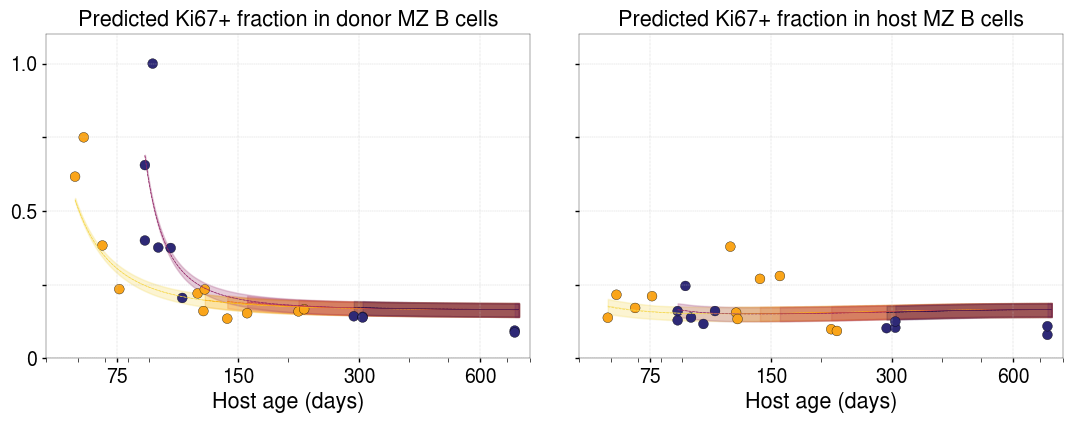

In [19]:
# global font size
sns.set_context("notebook", font_scale=1.3)
import matplotlib.pyplot as plt

# plot ki67 donor and host as subplots
my_pal = ['#FAA51A','#2e2976']

col_pal = sns.color_palette("inferno", n_colors=len(df_donor_allbmt['agebin'].unique()))
col_pal = col_pal[::-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
sns.lineplot(data=df_donor_allbmt, x='Host_Age', y='mean_pred', hue='agebin', palette=col_pal, linestyle='--',legend='full', ax=ax1, linewidth=0.5)    
sns.lineplot(data=df_host_allbmt, x='Host_Age', y='mean_pred', hue='agebin', palette=col_pal, linestyle='--', legend=False, ax=ax2, linewidth=0.5)  
sns.lineplot(data=df_donor_allbmt_T2, x='Host_Age', y='mean_pred', hue='agebin', palette=col_pal, legend='full',ax=ax1, linewidth=0.25)    
sns.lineplot(data=df_host_allbmt_T2, x='Host_Age', y='mean_pred', hue='agebin', palette=col_pal, legend=False, ax=ax2, linewidth=0.25) 
# Fill between for each agebin
for agebin, color in zip(df_donor_allbmt['agebin'].unique(), col_pal):
    df_bin = df_donor_allbmt[df_donor_allbmt['agebin'] == agebin]
    ax1.fill_between(df_bin['Host_Age'], df_bin['lb'], df_bin['ub'], color=color, alpha=0.125, label=f'BMT Age bin {agebin}')
    df_bin2 = df_host_allbmt[df_host_allbmt['agebin'] == agebin]
    ax2.fill_between(df_bin2['Host_Age'], df_bin2['lb'], df_bin2['ub'], color=color, alpha=0.125)

    
for agebin, color in zip(df_donor_allbmt['agebin'].unique(), col_pal):
    df_bin_T2 = df_donor_allbmt_T2[df_donor_allbmt_T2['agebin'] == agebin]
    ax1.fill_between(df_bin_T2['Host_Age'], df_bin_T2['lb'], df_bin_T2['ub'], color=color, alpha=0.125, label=f'BMT Age bin {agebin}')
    df_binT2 = df_host_allbmt_T2[df_host_allbmt_T2['agebin'] == agebin]
    ax2.fill_between(df_binT2['Host_Age'], df_binT2['lb'], df_binT2['ub'], color=color, alpha=0.125)
sns.scatterplot(data=df_adult, x='Age at S1K', y='frac_Ki67+_MZ_donor', hue='agebin', palette=my_pal, s=50, ax=ax1, edgecolor='black', linewidth=0.25, legend=False)
sns.scatterplot(data=df_adult, x='Age at S1K', y='frac_Ki67+_MZ_host', hue='agebin', palette=my_pal, s=50, ax=ax2, edgecolor='black', linewidth=0.25, legend=False)
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.set_title('Predicted Ki67+ fraction in donor MZ B cells')
ax1.legend_.remove()
ax1.set_xscale('log')
ax1.set_xlim(50, 800)
ax1.set_ylim(0, 1.1)
ax1.set_xticks([75, 150, 300, 600], [75, 150, 300, 600])
ax1.set_yticks(np.arange(0, 1.25, 0.25))
ax1.set_yticklabels([0,'' ,0.5,'',  1.0])

# Axis border width
for spine in ax1.spines.values():
    spine.set_linewidth(0.25)   # try 0.6 / 0.8 / 1.0

# Tick mark width
ax1.tick_params(axis='both', which='both', width=0.8)
ax1.grid(True, axis="x", ls="-.", color='silver', linewidth=0.25)
ax1.grid(True, axis="y", ls="--", color='silver', linewidth=0.25)
ax1.set_xlabel('Host age (days)')
ax1.tick_params(axis="both", labelsize=14)

# tick mark size and thickness
ax1.tick_params(axis="both", which="major", length=3, width=1)
ax1.tick_params(axis="both", which="minor", length=3, width=0.5)

ax2.set_ylabel('')
ax2.set_title('Predicted Ki67+ fraction in host MZ B cells')
ax2.set_xscale('log')
ax2.set_xlim(50, 800)
ax2.set_ylim(0, 1.1)
ax2.set_xticks([75, 150, 300, 600], [75, 150, 300, 600])
ax2.set_yticks(np.arange(0, 1.25, 0.25))

# # Exact 9 age values for colorbar labels
# agebins = np.sort(df_donor_allbmt['agebin'].unique()).astype(int) 
# age_labels = np.array([int(bmt_ages[i]) for i in agebins])     


# norm = plt.Normalize(vmin=age_labels.min()/7, vmax=age_labels.max()/7)
# sm = plt.cm.ScalarMappable(cmap='inferno_r', norm=norm)
# sm.set_array([])
# ax2 = plt.gca()
# cbar = plt.colorbar(sm, ax=ax2, fraction=0.03, pad=0.02, alpha=0.8)
# cbar.set_label('Age at BMT (weeks)')

# Axis border width
for spine in ax2.spines.values():
    spine.set_linewidth(0.25)   # try 0.6 / 0.8 / 1.0

# Tick mark width
ax2.tick_params(axis='both', which='both', width=0.8)
ax2.grid(True, axis="x", ls="-.", color='silver', linewidth=0.25)
ax2.grid(True, axis="y", ls="--", color='silver', linewidth=0.25)
ax2.set_xlabel('Host age (days)')
ax2.tick_params(axis="both", labelsize=14)

# tick mark size and thickness
ax2.tick_params(axis="both", which="major", length=3, width=1)
ax2.tick_params(axis="both", which="minor", length=3, width=0.5)

plt.tight_layout()
fig.subplots_adjust(wspace=0.1)

# save both figures
fig.savefig('Fig4D_varS.pdf', dpi=300)

In [20]:
df_allbmt = pd.DataFrame()
df_allbmt_T2 = pd.DataFrame()

for i in range(len(bmt_ages)):
    age_at_bmt = bmt_ages[i]
    solve_time_start = solve_times[i]
    df_summary = get_ode_summary(phi1, phi01, r1, b1, d1, k1, age_at_bmt=age_at_bmt, solve_time_start=solve_time_start, n_samples=1000, oupt='Nfd')
    df_summary['agebin'] = i
    df_allbmt = pd.concat([df_allbmt, df_summary], axis=0)
    
for i in range(len(bmt_ages)):
    age_at_bmt = bmt_ages[i]
    solve_time_start = solve_times[i]
    df_summary_T2 = get_ode_summary_T2(phi2, phi02, r2, b2, d2, k2, age_at_bmt=age_at_bmt, solve_time_start=solve_time_start, n_samples=1000, oupt='Nfd')
    df_summary_T2['agebin'] = i
    df_allbmt_T2 = pd.concat([df_allbmt_T2, df_summary_T2], axis=0)


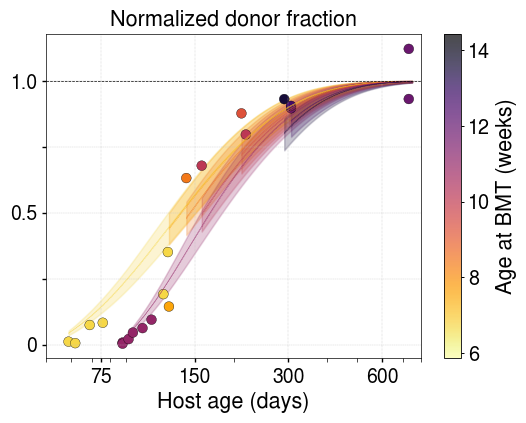

In [21]:
# plot NFd


fig, ax = plt.subplots(figsize=(5.6, 4.5))
sns.lineplot(data=df_allbmt, x='Host_Age', y='mean_pred', hue='agebin', palette=col_pal, linestyle='--',legend='full', ax=ax, linewidth=0.25)
sns.lineplot(data=df_allbmt_T2, x='Host_Age', y='mean_pred', hue='agebin', palette=col_pal, legend='full', ax=ax, linewidth=0.25)

# Fill between for each agebin
for agebin, color in zip(df_allbmt['agebin'].unique(), col_pal):
	df_bin = df_allbmt[df_allbmt['agebin'] == agebin]
	ax.fill_between(df_bin['Host_Age'], df_bin['lb'], df_bin['ub'], color=color, alpha=0.125, label=f'BMT Age bin {agebin}')

for agebin, color in zip(df_allbmt_T2['agebin'].unique(), col_pal):
    df_bin_T2 = df_allbmt_T2[df_allbmt_T2['agebin'] == agebin]
    ax.fill_between(df_bin_T2['Host_Age'], df_bin_T2['lb'], df_bin_T2['ub'], color=color, alpha=0.125, label=f'BMT Age bin {agebin}')
 
sns.scatterplot(data=df_adult, x='Age at S1K', y='Nfd_MZ', hue='Age at BMT', palette=col_pal, s=50, edgecolor='black', linewidth=0.25, legend=False, ax=ax)
ax.set_xlabel('Host Age (days)')
ax.set_ylabel('Normalized Donor Fraction (Nfd)')
ax.set_title('Predicted Nfd over Host Age for Different BMT Ages')
ax.set_xlim(50, 800)
ax.set_xscale('log')
ax.set_xticks([75, 150,  300,  600])
ax.set_xticklabels([75, 150,  300,  600])
ax.set_ylabel('')
ax.set_yticks(np.arange(0, 1.25, 0.25))
ax.set_yticklabels([0,'' ,0.5,'',  1.0])
ax.set_xlabel('Host age (days)')
ax.set_title('Normalized donor fraction')
ax.axhline(y=1, color='black', linestyle='dashed', linewidth=0.5)

# Exact 9 age values for colorbar labels
agebins = np.sort(df_donor_allbmt['agebin'].unique()).astype(int) 
age_labels = np.array([int(bmt_ages[i]) for i in agebins])     


norm = plt.Normalize(vmin=age_labels.min()/7, vmax=age_labels.max()/7)
sm = plt.cm.ScalarMappable(cmap='inferno_r', norm=norm)
sm.set_array([])
ax2 = plt.gca()
cbar = plt.colorbar(sm, ax=ax, alpha=0.7)
cbar.set_label('Age at BMT (weeks)')
cbar.ax.tick_params(length=2, width=0.7)
# optional: fewer ticks
cbar.set_ticks([6, 8, 10, 12, 14]) 

# optional: thinner border
cbar.outline.set_linewidth(0.6)

# Axis border width
for spine in ax.spines.values():
    spine.set_linewidth(0.5)   # try 0.6 / 0.8 / 1.0

# Tick mark width
ax.tick_params(axis='both', which='both', width=1)
ax.grid(True, axis="x", ls="-.", color='silver', linewidth=0.25)
ax.grid(True, axis="y", ls="--", color='silver', linewidth=0.25)
# tick label font size
ax.tick_params(axis="both", labelsize=14)

# tick mark size and thickness
ax.tick_params(axis="both", which="major", length=3, width=1)
ax.tick_params(axis="both", which="minor", length=3, width=0.5)
# no legend 
ax.legend([],[], frameon=False)
plt.tight_layout()


# save the figure
plt.savefig('Fig4C_varS.pdf', dpi=300)

In [22]:
df_counts = pd.DataFrame()
df_counts_T2 = pd.DataFrame()

for i in range(len(bmt_ages)):
    age_at_bmt = bmt_ages[i]
    solve_time_start = solve_times[i]
    df_summary = get_ode_summary(phi1, phi01, r1, b1, d1, k1, age_at_bmt=age_at_bmt, solve_time_start=solve_time_start, n_samples=1000, oupt='counts')
    df_summary['agebin'] = i
    df_counts = pd.concat([df_counts, df_summary], axis=0)
    
for i in range(len(bmt_ages)):
    age_at_bmt = bmt_ages[i]
    solve_time_start = solve_times[i]
    df_summary_T2 = get_ode_summary_T2(phi2, phi02, r2, b2, d2, k2, age_at_bmt=age_at_bmt, solve_time_start=solve_time_start, n_samples=1000, oupt='counts')
    df_summary_T2['agebin'] = i
    df_counts_T2 = pd.concat([df_counts_T2, df_summary_T2], axis=0)


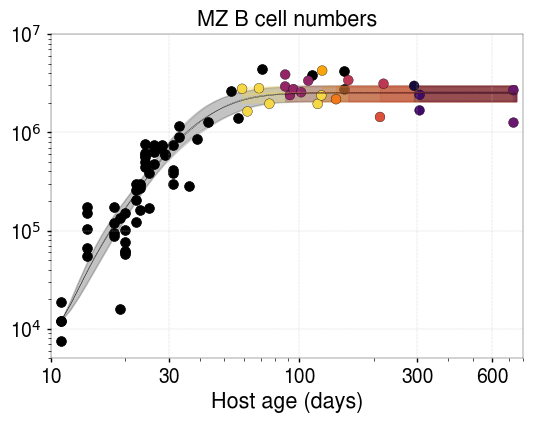

In [23]:
col_pal = sns.color_palette("inferno", n_colors=len(df_counts['agebin'].unique()))
col_pal = col_pal[::-1]
# plot counts
ts1= np.arange(59, 750, 1)
ts2= np.arange(88, 750, 1)

def _stack_samples(samples, n_time):
    """Convert list of trajectories into a fixed 2D array (n_samples, n_time)."""
    arr = np.full((len(samples), n_time), np.nan, dtype=float)
    for i, s in enumerate(samples):
        s = np.asarray(s, dtype=float).reshape(-1)
        n = min(n_time, s.size)
        arr[i, :n] = s[:n]
    return arr

n_time = len(time_points_counts)
y_pred_samples_T1_arr = _stack_samples(y_pred_samples_T1, n_time)
y_pred_samples_T2_arr = _stack_samples(y_pred_samples_T2, n_time)

fig, ax = plt.subplots(figsize=(5.6, 4.5))
sns.lineplot(data=df_counts, x='Host_Age', y='mean_pred', hue='agebin', linestyle='--', palette=col_pal, legend='full', ax=ax, linewidth=0.25)
sns.lineplot(data=df_counts_T2, x='Host_Age', y='mean_pred', hue='agebin', palette=col_pal, legend='full', ax=ax, linewidth=0.25)

sns.scatterplot(data=df_ont, x='age.at.S1K', y='total_MZ', s=50, color='black', edgecolor='black', linewidth=0.5, label='Young WT mice', legend=False)
plt.plot(time_points_counts, np.nanmedian(y_pred_samples_T1_arr, axis=0), linestyle='--', color='black', linewidth=0.25)
plt.plot(time_points_counts, np.nanmedian(y_pred_samples_T2_arr, axis=0), color='black', linewidth=0.25)

plt.fill_between(time_points_counts,
                 np.nanpercentile(y_pred_samples_T1_arr, 2.5, axis=0),
                 np.nanpercentile(y_pred_samples_T1_arr, 97.5, axis=0),
                 color='black', alpha=0.125)

plt.fill_between(time_points_counts,
                 np.nanpercentile(y_pred_samples_T2_arr, 2.5, axis=0),
                 np.nanpercentile(y_pred_samples_T2_arr, 97.5, axis=0),
                 color='black', alpha=0.125)
# Fill between for each agebin
for agebin, color in zip(df_counts['agebin'].unique(), col_pal):
    df_bin = df_counts[df_counts['agebin'] == agebin]
    ax.fill_between(df_bin['Host_Age'], df_bin['lb'], df_bin['ub'], color=color, alpha=0.125, label=f'BMT Age bin {agebin}')
    
for agebin, color in zip(df_counts['agebin'].unique(), col_pal):
    df_bin_T2 = df_counts_T2[df_counts_T2['agebin'] == agebin]
    ax.fill_between(df_bin_T2['Host_Age'], df_bin_T2['lb'], df_bin_T2['ub'], color=color, alpha=0.125, label=f'BMT Age bin {agebin}')
    
sns.scatterplot(data=df_adult, x='Age at S1K', y='total_MZ', hue='Age at BMT', palette=col_pal, s=50, edgecolor='black', linewidth=0.25, legend=False, ax=ax)
ax.set_xlabel('Host age (days)')
ax.set_title('MZ B cell numbers')
ax.set_ylabel('')
ax.set_xlim(10, 800)
ax.set_xscale('log')
ax.set_ylim(5*1e3, 1e7)
ax.set_xticks([10, 30, 100, 300, 600])
ax.set_xticklabels([10, 30, 100, 300, 600])
ax.set_yscale('log')
ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
# y axis ticks as 10^4, 10^5, 10^6, 10^7
ax.set_yticks([1e4, 1e5, 1e6, 1e7])
ax.set_yticklabels(['10$^4$','10$^5$', '10$^6$', '10$^7$'])

# Axis border width
for spine in ax.spines.values():
    spine.set_linewidth(0.25)   # try 0.6 / 0.8 / 1.0

# Tick mark width
ax.tick_params(axis='both', which='both', width=0.8)
ax.grid(True, axis="x", ls="-.", color='silver', linewidth=0.25)
ax.grid(True, axis="y", ls="--", color='silver', linewidth=0.25)
ax.tick_params(axis="both", labelsize=14)

# tick mark size and thickness
ax.tick_params(axis="both", which="major", length=3, width=1)
ax.tick_params(axis="both", which="minor", length=2, width=0.5)
# no legend
plt.legend([],[], frameon=False)
plt.tight_layout()
# save the figure
plt.savefig('Fig4B_varS.pdf', dpi=300)

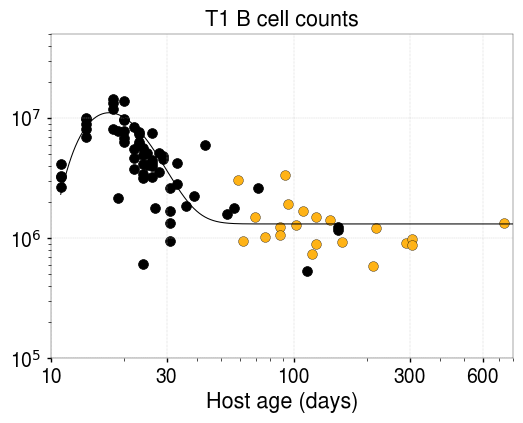

In [24]:
def P(t):
    theta_0 = np.exp(14.09)
    nu = 0.27
    n = 2
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))
    

df_adult1 = df_adult.iloc[:-1]

# Plot T1 AA4.1 counts

fig, ax = plt.subplots(1, 1, figsize=(5.5,4.5))
# sns.scatterplot(data=df_new, x='Age at S1K', y='total_T1_AA4.1+', alpha=0.85 ,s=85, color = 'black', legend=False)
sns.scatterplot(data=df_adult1, x='Age at S1K', y='total_T1_AA4.1+', color='#FFB316',  s=50, edgecolor='black', linewidth=0.25, legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='total_T1_AA4.1+', s=50, color = 'black', edgecolor='black', linewidth=0.5, legend=False)
ax.plot(np.arange(11, 800, 0.05), P(np.arange(11, 800, 0.05)), color= 'black',  linewidth=0.75)
ax.set_xlabel('Host age (days)')
ax.set_title('T1 B cell counts')
ax.set_ylabel('')
ax.set_xlim(10, 800)
ax.set_xscale('log')
ax.set_ylim(1e5, 5*1e7)
ax.set_xticks([10, 30, 100, 300, 600])
ax.set_xticklabels([10, 30, 100, 300, 600])
ax.set_yscale('log')
ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
# y axis ticks as 10^4, 10^5, 10^6, 10^7
ax.set_yticks([1e5, 1e6, 1e7])
ax.set_yticklabels(['10$^5$', '10$^6$', '10$^7$'])

# Axis border width
for spine in ax.spines.values():
    spine.set_linewidth(0.25)   # try 0.6 / 0.8 / 1.0

# Tick mark width
ax.tick_params(axis='both', which='both', width=0.8)
ax.grid(True, axis="x", ls="-.", color='silver', linewidth=0.25)
ax.grid(True, axis="y", ls="--", color='silver', linewidth=0.25)
ax.tick_params(axis="both", labelsize=14)

# tick mark size and thickness
ax.tick_params(axis="both", which="major", length=3, width=1)
ax.tick_params(axis="both", which="minor", length=2, width=0.5)
# no legend
plt.legend([],[], frameon=False)
plt.tight_layout()
# save the figure
plt.savefig('T1_precursor.pdf', dpi=300)

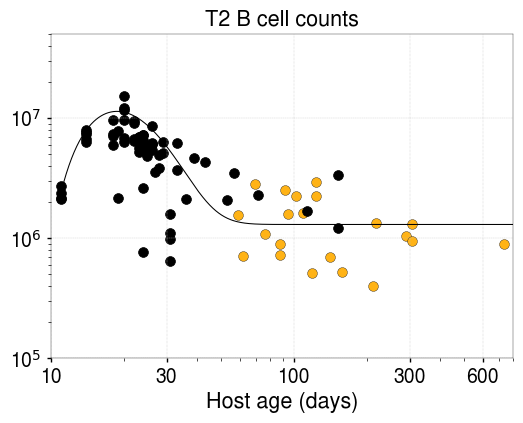

In [25]:
def P(t):
    theta_0 = np.exp(14.08)
    nu = 0.2
    n = 1.75
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))

# Plot T2 counts
fig, ax = plt.subplots(1, 1, figsize=(5.5,4.5))

sns.scatterplot(data=df_adult1, x='Age at S1K', y='total_T2', color='#FFB316', s=50, edgecolor='black', linewidth=0.25, legend=False)
sns.scatterplot(data=df_ont_T2, x='age.at.S1K', y='Transitional2', s=50, color = 'black', edgecolor='black', linewidth=0.5, legend=False)
ax.plot(np.arange(11, 800, 0.05), P(np.arange(11, 800, 0.05)), color= 'black',  linewidth=0.75)
ax.set_xlabel('Host age (days)')
ax.set_title('T2 B cell counts')
ax.set_ylabel('')
ax.set_xlim(10, 800)
ax.set_xscale('log')
ax.set_ylim(1e5, 5*1e7)
ax.set_xticks([10, 30, 100, 300, 600])
ax.set_xticklabels([10, 30, 100, 300, 600])
ax.set_yscale('log')
ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
# y axis ticks as 10^4, 10^5, 10^6, 10^7
ax.set_yticks([1e5, 1e6, 1e7])
ax.set_yticklabels(['10$^5$', '10$^6$', '10$^7$'])

# Axis border width
for spine in ax.spines.values():
    spine.set_linewidth(0.25)   # try 0.6 / 0.8 / 1.0

# Tick mark width
ax.tick_params(axis='both', which='both', width=0.8)
ax.grid(True, axis="x", ls="-.", color='silver', linewidth=0.25)
ax.grid(True, axis="y", ls="--", color='silver', linewidth=0.25)
ax.tick_params(axis="both", labelsize=14)

# tick mark size and thickness
ax.tick_params(axis="both", which="major", length=3, width=1)
ax.tick_params(axis="both", which="minor", length=2, width=0.5)
# no legend
plt.legend([],[], frameon=False)
plt.tight_layout()
# save the figure
plt.savefig('T2_precursor.pdf', dpi=300)


(1000, 1) (5000,) (5000,)
(1000, 5000)


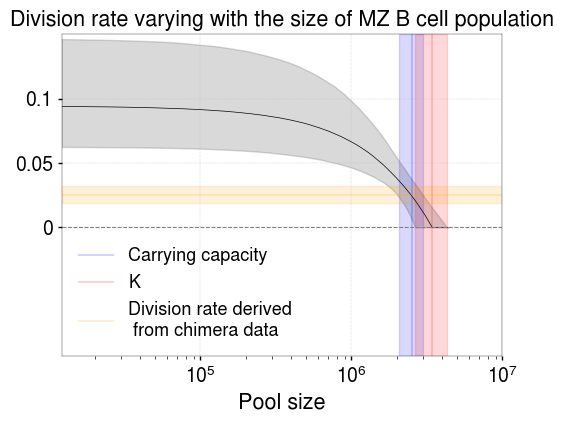

In [68]:
def b_m(M, b, K):
    return b * (1 - (M / K))

M = np.logspace(4.0812756, 6.64, 1000)
# lamda = lamda_samples
# phi = (lamda_samples * M_stable_samples)/ 1308516
b = unified_T2.b
k = unified_T2.K

M_stable = unified_T2.totalMz_pred[:, -1]
# Reshape M to broadcast properly with posterior samples
M_broadcast = M[:, np.newaxis]  # Shape: (len(M), 1)
print(M_broadcast.shape, b.shape, k.shape)
b_samples = b_m(M_broadcast, b, k)  # Shape: (len(M), n_samples)

# #Filter our negative b values 
b_samples = np.where(b_samples < 0, 0, b_samples)
print(b_samples.shape)

# Remove any x positions whose posterior summary dips below zero
b_median = np.median(b_samples, axis=1)  
b_lower = np.percentile(b_samples, 2.5, axis=1)
b_upper = np.percentile(b_samples, 97.5, axis=1)
# valid_mask = (b_median >= 0) 
# M_plot = M[valid_mask]
# b_median = b_median[valid_mask]
# valid_mask2 = (b_lower >= 0) 
# b_lower = b_lower[valid_mask2]
# # b_upper = b_upper[valid_mask2]
# M_plot2 = M[valid_mask2]


fig, axes = plt.subplots(1, 1, figsize=(5.5,4.5))
axes.plot(M, b_median, color='black', linewidth=0.5)
# axes.plot(M, b_lower, color='grey', linewidth=0.25)
# axes.plot(M, b_upper, color='grey', linewidth=0.25)
axes.fill_between(M, b_lower, b_upper, alpha=0.15, color='black')



plt.axvline(x=np.median(M_stable), color='blue',  label='Carrying capacity', linewidth=0.25)
plt.axvspan(np.quantile(M_stable, 0.025), np.quantile(M_stable, 0.975), color='blue', alpha=0.15)

plt.axvline(x=np.median(unified_T2.K), color='red', label='K', linewidth=0.25)
plt.axvspan(np.quantile(unified_T2.K, 0.025), np.quantile(unified_T2.K, 0.975), color='red', alpha=0.15)

# plt.axhline(y=np.median(SHM_df.rho), color='black', linestyle='--', label='Adult division rate (SHM)')
# plt.axhspan(np.quantile(SHM_df.rho, 0.025), np.quantile(SHM_df.rho, 0.975), color='black', alpha=0.2)

plt.axhline(y=np.median(SHM_df_T2.rho), color='orange',  label='Division rate derived \n from chimera data', linewidth=0.25)
plt.axhspan(np.quantile(SHM_df_T2.rho, 0.025), np.quantile(SHM_df_T2.rho, 0.975), color='orange', alpha=0.15)

plt.axhline(y=0, color='grey', linestyle='--', linewidth=0.75)
axes.set_xlim(12058, 1e7)
axes.set_ylim(-0.1, 0.15)
axes.set_xticks([1e5, 1e6, 1e7])
axes.set_xticklabels([ '10^5', '10^6', '10^7'])
axes.set_yticks([ 0, 0.05, 0.1])
axes.set_yticklabels(['0', '0.05', '0.1'])
axes.set_xscale('log')
# axes.set_ylabel(r'$b(M)$')
ax = plt.gca()

# Axis border width
for spine in ax.spines.values():
    spine.set_linewidth(0.25)   # try 0.6 / 0.8 / 1.0
plt.title('Division rate varying with the size of MZ B cell population')
axes.set_xlabel('Pool size')
axes.grid(True, axis="x", ls="-.", color='silver', linewidth=0.25)
axes.grid(True, axis="y", ls="--", color='silver', linewidth=0.25)
axes.legend(fontsize='small', frameon=False, loc='lower left')
ax.tick_params(axis="both", labelsize=14)

# tick mark size and thickness
ax.tick_params(axis="both", which="major", length=3, width=1)
ax.tick_params(axis="both", which="minor", length=2, width=0.5)
plt.tight_layout()

#save figure
plt.savefig('figures/Fig5B_varS.pdf', dpi=300)
plt.show()

(7390, 5000)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


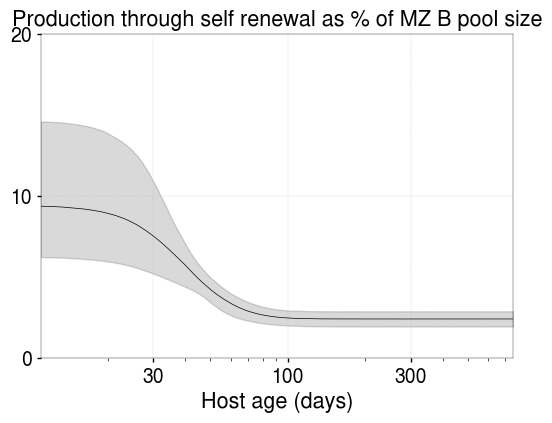

In [69]:
# Define the ODE function with signature (t, y, *args) required by solve_ivp
def ode_function(t, y, phi, phi0, r, b, d, K):
    M_val = y[0]
    dMdt = q(t, phi, phi0, r)*P2(t) + b_m(M_val, b, K) * M_val - d*M_val
    
    return [dMdt]

# Use posterior means (or derive S from posterior samples)
phi = unified_T2.phi
phi0 = unified_T2.phi0
r = unified_T2.r
b = unified_T2.b
d = unified_T2.d
K = unified_T2.K

# Compute S using posterior samples to get a representative mean source if desired
# This avoids mixing scalar means incorrectly.
# S = lamda * data_neutral.M_stable

M0 = [12058.0]
# use a reasonable time step (very small dt can make solver struggle); 0.1 matches other cells
t_ev = np.arange(11.0, 750.0, 0.1)
sol = np.zeros((len(t_ev), len(b)))  # Preallocate solution array
for i in range(len(b)):
    # Solve once over the full interval (vectorized call) instead of calling solve_ivp in a loop
    result = solve_ivp(ode_function,
                        [t_ev[0], t_ev[-1]],
                M0,
                t_eval=t_ev,
                args=(phi[i], phi0[i], r[i], b[i], d[i], K[i]))
    sol[:, i] = result.y[0]

print(sol.shape)  # Should be (len(t_ev), len(b))
# Extract solution and compute r(t)
b_t = np.zeros((len(t_ev), len(b)))
b_t_max = np.zeros((len(b)))
M_t_max = np.zeros(len(b))
for i in range(len(b)):
    M_t = sol[:, i]
    M_t_max[i] = sol[:, i].max()
    b_t[:, i] = b_m(M_t, b[i], K[i])*100
    b_t_max[i] = b_m(M_t_max[i], b[i], K[i])
    

# Calculate statistics
b_median = np.median(b_t, axis=1)
b_lower = np.percentile(b_t, 2.5, axis=1)
b_upper = np.percentile(b_t, 97.5, axis=1)

fig, axes = plt.subplots(1, 1, figsize=(5.5, 4.5))
axes.plot(t_ev, b_median, color='black', linewidth=0.5)
axes.fill_between(t_ev, b_lower, b_upper, alpha=0.15, color='black')
# plt.axhline(y=0, color='grey', linestyle='--')
# plt.axhline(y=-np.mean(data_DDM.stan_variable('lambda'), axis=0), color='orange', linestyle='--', label='Growth Rate')
# plt.yscale('log')
# plt.axhline(y=np.median(SHM_df_T2.rho), color='orange', label='Division rate derived \n from chimera data', linewidth=0.25)
# plt.axhspan(np.quantile(SHM_df_T2.rho, 0.025), np.quantile(SHM_df_T2.rho, 0.975), color='orange', alpha=0.15)
# plt.axhline(y=np.median(posterior_df.rho), color='orange', linestyle='--', label='Adult division rate (Ontogeny)')
# plt.axhspan(np.quantile(posterior_df.rho, 0.025), np.quantile(posterior_df.rho, 0.975), color='orange', alpha=0.2)
# axes.set_ylim(0, 0.16)
# plt.yticks([0.0, 0.05, 0.1, 0.15], [0.0, 0.05, 0.1, 0.15])
axes.set_ylim(0, 20)
plt.yticks([0, 10, 20], [0, 10, 20])
axes.set_xlim(11, 750)
plt.xscale('log')
plt.xticks([ 30, 100, 300], [ 30, 100, 300])
axes.set_ylabel('')
ax = plt.gca()

# Axis border width
for spine in ax.spines.values():
    spine.set_linewidth(0.25)   # try 0.6 / 0.8 / 1.0

# Tick mark width
# ax.tick_params(axis='both', which='both', width=0.8)
plt.title('Production through self renewal as % of MZ B pool size')
# axes.set_ylabel(r'$b(t)$')
axes.set_xlabel('Host age (days)')
ax.tick_params(axis="both", labelsize=14)

# tick mark size and thickness
ax.tick_params(axis="both", which="major", length=3, width=1)
ax.tick_params(axis="both", which="minor", length=2, width=0.5)
axes.grid(True, axis="x", ls="-.", color='silver', linewidth=0.25)
axes.grid(True, axis="y", ls="--", color='silver', linewidth=0.25)
plt.tight_layout()
axes.legend(fontsize='x-small', frameon=False)
#save figure
plt.savefig('figures/Fig5C_varS.pdf', dpi=300)
plt.show()

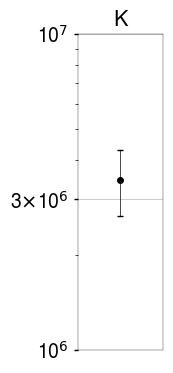

In [70]:
#Plot K

def plot_with_error_bars(data, color, ax):
    mean_data = np.mean(data, axis=0)
    lower_ci = np.quantile(data, 0.025, axis=0)
    upper_ci = np.quantile(data, 0.975, axis=0)
    
    # Ensure mean_rho_inv, lower_ci, and upper_ci are arrays
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    x_values = np.arange(len(mean_data))
    
    ax.errorbar(x_values, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color= color, capsize=2, markersize=4, elinewidth=0.5)
    
fig, ax = plt.subplots(1, 1, figsize=(2, 4))
plot_with_error_bars(k ,'black', ax)
ax.set_ylim(1e6, 1e7)
ax.set_yscale('log')
ax.set_yticks([1e6, 3e6, 1e7])
ax.set_yticklabels(['10$^6$', '3$\\times$10$^6$', '10$^7$'], fontsize=14)
ax.set_xticklabels([])
ax.set_xticks([])
ax.set_title('K')
ax = plt.gca()

# Axis border width
for spine in ax.spines.values():
    spine.set_linewidth(0.25) 
ax.tick_params(axis="y", which="major", length=3, width=1)
ax.tick_params(axis="y", which="minor", length=2, width=0.5)
# ax.grid(which='major', axis='y', linestyle='-', linewidth=0.5, alpha=0.9)
# ax.grid(which='minor', axis='y', linestyle='-', linewidth=0.5, alpha=0.9)


ax.yaxis.grid(True, linestyle='-', linewidth=0.5, alpha=0.9)
plt.tight_layout()
plt.savefig('Ontogeny_K_parameter.pdf', dpi=300)
plt.show()

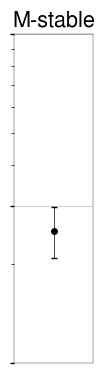

In [71]:
#Plot carrying capacity

def plot_with_error_bars(data, color, ax):
    mean_data = np.mean(data, axis=0)
    lower_ci = np.quantile(data, 0.025, axis=0)
    upper_ci = np.quantile(data, 0.975, axis=0)
    
    # Ensure mean_rho_inv, lower_ci, and upper_ci are arrays
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    x_values = np.arange(len(mean_data))
    
    ax.errorbar(x_values, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color= color, capsize=2, markersize=4, elinewidth=0.5)
    
fig, ax = plt.subplots(1, 1, figsize=(1.3, 4))
plot_with_error_bars(M_t_max,'black', ax)
ax.set_ylim(1e6, 1e7)
ax.set_yscale('log')
ax.set_yticks([1e6, 3e6, 1e7])
ax.set_yticklabels([], fontsize=14)
ax.set_xticklabels([])
ax.set_xticks([])
ax.set_title('M-stable')
ax = plt.gca()

# Axis border width
for spine in ax.spines.values():
    spine.set_linewidth(0.25) 
ax.tick_params(axis="both", which="major", length=3, width=1)
ax.tick_params(axis="both", which="minor", length=2, width=0.5)
# ax.set_xlabel('Turnover \n Time', fontsize=10)

ax.yaxis.grid(True, linestyle='-', linewidth=0.5, alpha=0.9)
# ax.grid(which='minor', axis='y', linestyle='-', linewidth=0.5, alpha=0.9)
plt.tight_layout()
plt.savefig('Ontogeny_M_stable.pdf', dpi=300)
plt.show()

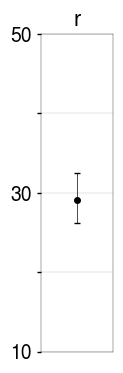

Upper and lower confidence intervals calculated. Lower CI: 2.841571948800002 Upper CI: 3.4711355262000048


In [72]:
#Plot r

def plot_with_error_bars(data, label, color, ax):
    mean_data = np.mean(data, axis=0)
    lower_ci = np.quantile(data, 0.025, axis=0)
    upper_ci = np.quantile(data, 0.975, axis=0)
    
    # Ensure mean_rho_inv, lower_ci, and upper_ci are arrays
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    x_values = np.arange(len(mean_data))
    
    ax.errorbar(x_values, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color= color, capsize=2, markersize=4, elinewidth=0.5)
    
fig, ax = plt.subplots(1, 1, figsize=(1.5, 4))
plot_with_error_bars(r, '' ,'black', ax)
ax.set_yticks([10, 20, 30, 40, 50])
ax.set_yticklabels(['10', '', '30', '', '50'], fontsize=14)
ax.set_xticklabels([])
ax.set_xticks([])
ax.set_title('r')
ax = plt.gca()

# Axis border width
for spine in ax.spines.values():
    spine.set_linewidth(0.25) 
ax.tick_params(axis="both", which="major", length=3, width=1)
ax.tick_params(axis="both", which="minor", length=2, width=0.5)
# ax.set_xlabel('Turnover \n Time', fontsize=10)


ax.yaxis.grid(True, linestyle='-', linewidth=0.25, alpha=0.9)
plt.tight_layout()
plt.savefig('Ontogeny_r_parameter.pdf', dpi=300)
plt.show()

mean_data = np.mean(r, axis=0)
lower_ci = np.quantile(r, 0.025, axis=0)
upper_ci = np.quantile(r, 0.975, axis=0)

print(
    "Upper and lower confidence intervals calculated. "
    "Lower CI:", mean_data - lower_ci,
    "Upper CI:", upper_ci - mean_data
)

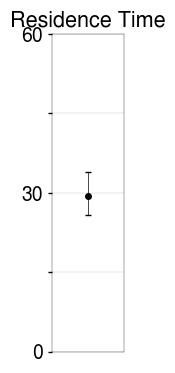

Mean residence time (days): 29.43255420753029
Upper bound: 33.879470609874026
Lower bound: 25.74772927348352


In [73]:
# Residence time 

residence_time = 1 / unified_T2.d

def plot_with_error_bars_res(data, label, color, ax):
    mean_data = np.mean(data, axis=0)
    lower_ci = np.quantile(data, 0.025, axis=0)
    upper_ci = np.quantile(data, 0.975, axis=0)
    
    # Ensure mean_rho_inv, lower_ci, and upper_ci are arrays
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    x_values = np.arange(len(mean_data))
    
    ax.errorbar(x_values, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color= color, capsize=2, markersize=4, elinewidth=0.5)
    
fig, ax = plt.subplots(1, 1, figsize=(1.5, 4))
plot_with_error_bars_res(residence_time, '' ,'black', ax)
ax.set_yticks([0, 15, 30, 45, 60])
ax.set_yticklabels(['0', '', '30', '', '60'], fontsize=14)
ax.set_xticklabels([])
ax.set_xticks([])
ax.set_title('Residence Time')
ax = plt.gca()

# Axis border width
for spine in ax.spines.values():
    spine.set_linewidth(0.25) 
ax.tick_params(axis="both", which="major", length=3, width=1)
ax.tick_params(axis="both", which="minor", length=2, width=0.5)
# ax.set_xlabel('Turnover \n Time', fontsize=10)


ax.yaxis.grid(True, linestyle='-', linewidth=0.25, alpha=0.9)
plt.tight_layout()
plt.savefig('Ontogeny_Residence_Time_parameter.pdf', dpi=300)
plt.show()
print('Mean residence time (days):', np.mean(residence_time))
print('Upper bound:', np.quantile(residence_time, 0.975))
print('Lower bound:', np.quantile(residence_time, 0.025))

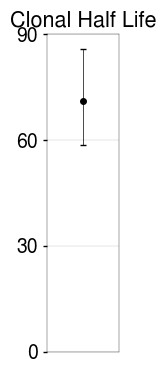

Mean clonal half life at carrying capacity (days): 70.89985150217069
Upper bound: 85.67952318494876
Lower bound: 58.614637342175605


In [74]:
#Plot clonal half life at carrying capacity

clonal_half_life = np.log(2) / (unified_T2.d - b_t_max)

def plot_with_error_bars_clo(data, color, ax):
    mean_data = np.mean(data, axis=0)
    lower_ci = np.quantile(data, 0.025, axis=0)
    upper_ci = np.quantile(data, 0.975, axis=0)
    
    # Ensure mean_rho_inv, lower_ci, and upper_ci are arrays
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    x_values = np.arange(len(mean_data))
    
    ax.errorbar(x_values, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color= color, capsize=2, markersize=4, elinewidth=0.5)
    
fig, ax = plt.subplots(1, 1, figsize=(1.5, 4))
plot_with_error_bars_clo(clonal_half_life, 'black', ax)
ax.set_yticks([0, 30, 60, 90])
ax.set_yticklabels(['0', '30', '60', '90'], fontsize=14)
ax.set_xticklabels([])
ax.set_xticks([])
ax.set_title('Clonal Half Life')
ax = plt.gca()

# Axis border width
for spine in ax.spines.values():
    spine.set_linewidth(0.25) 
ax.tick_params(axis="both", which="major", length=3, width=1)
ax.tick_params(axis="both", which="minor", length=2, width=0.5)
# ax.set_xlabel('Turnover \n Time', fontsize=10)


ax.yaxis.grid(True, linestyle='-', linewidth=0.25, alpha=0.9)
plt.tight_layout()
plt.savefig('Ontogeny_Clonal_Half_Life_parameter.pdf', dpi=300)
plt.show()
print('Mean clonal half life at carrying capacity (days):', np.mean(clonal_half_life))
print('Upper bound:', np.quantile(clonal_half_life, 0.975))
print('Lower bound:', np.quantile(clonal_half_life, 0.025))

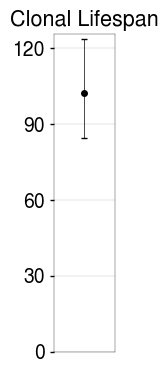

Mean clonal lifespan at carrying capacity (days): 102.28686416194559
Upper bound: 123.60942320465655
Lower bound: 84.56304661706179


In [75]:
#Plot clonal half life at carrying capacity

clonal_lifespan = 1 / (unified_T2.d - b_t_max)

def plot_with_error_bars_clo(data, color, ax):
    mean_data = np.mean(data, axis=0)
    lower_ci = np.quantile(data, 0.025, axis=0)
    upper_ci = np.quantile(data, 0.975, axis=0)
    
    # Ensure mean_rho_inv, lower_ci, and upper_ci are arrays
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    x_values = np.arange(len(mean_data))
    
    ax.errorbar(x_values, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color= color, capsize=2, markersize=4, elinewidth=0.5)
    
fig, ax = plt.subplots(1, 1, figsize=(1.5, 4))
plot_with_error_bars_clo(clonal_lifespan, 'black', ax)
ax.set_yticks([0, 30, 60, 90, 120])
ax.set_yticklabels(['0', '30', '60', '90', '120'], fontsize=14)
ax.set_xticklabels([])
ax.set_xticks([])
ax.set_title('Clonal Lifespan')
ax = plt.gca()

# Axis border width
for spine in ax.spines.values():
    spine.set_linewidth(0.25) 
ax.tick_params(axis="both", which="major", length=3, width=1)
ax.tick_params(axis="both", which="minor", length=2, width=0.5)
# ax.set_xlabel('Turnover \n Time', fontsize=10)


ax.yaxis.grid(True, linestyle='-', linewidth=0.25, alpha=0.9)
plt.tight_layout()
plt.savefig('Fig5I_clonallifespan.pdf', dpi=300)
plt.show()
print('Mean clonal lifespan at carrying capacity (days):', np.mean(clonal_lifespan))
print('Upper bound:', np.quantile(clonal_lifespan, 0.975))
print('Lower bound:', np.quantile(clonal_lifespan, 0.025))

In [83]:
# #Plot interdivision time on continuous time axis
# t_ev = np.arange(11, 750, 0.1)
# month_ticks = [0.5, 2, 4]
# day_ticks = np.array(month_ticks) * 30
# interdivision_time = 1 / b_t
# idx = np.array([np.argmin(np.abs(t_ev - tp)) for tp in day_ticks])
# interdivision_time1 = 1 / b_t[idx, :]

# def plot_with_error_bars_interdiv(data, color, ax):
#     mean_data = np.mean(data, axis=1)
#     lower_ci = np.quantile(data, 0.025, axis=1)
#     upper_ci = np.quantile(data, 0.975, axis=1)
    
#     # Ensure mean_rho_inv, lower_ci, and upper_ci are arrays
#     mean_data = np.atleast_1d(mean_data)
#     lower_ci = np.atleast_1d(lower_ci)
#     upper_ci = np.atleast_1d(upper_ci)
#     x_values = day_ticks
    
#     ax.errorbar(x_values, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], fmt='o',
#                color= color, capsize=2, markersize=4, elinewidth=0.5)
    
# fig, ax = plt.subplots(1, 1, figsize=(3, 4))
# plot_with_error_bars_interdiv(interdivision_time1, 'black', ax)

# #Plot curve for interdivision time
# mean_interdivision_time = 1 / b_median
# lower_interdivision_time = 1 / b_upper  # Invert upper bound for lower bound
# upper_interdivision_time = 1 / b_lower  # Invert lower bound for upper bound
# ax.plot(t_ev, mean_interdivision_time, color='black', linewidth=0.5)
# ax.fill_between(t_ev, lower_interdivision_time, upper_interdivision_time, alpha=0.15, color='black')
# ax.set_yticks([0, 15, 30, 45, 60])
# ax.set_yticklabels(['0', '', '30', '', '60'], fontsize=14)
# ax.set_xlim(11, 150)
# # ax.set_xscale('log')
# ax.set_xticks(day_ticks)
# ax.set_xticklabels(month_ticks, fontsize=14)
# ax.set_xlabel('Host age (months)', fontsize=14)
# ax.set_title('Interdivision Time', fontsize=14)
# ax = plt.gca()  
# # Axis border width
# for spine in ax.spines.values():
#     spine.set_linewidth(0.25)
# ax.tick_params(axis="both", which="major", length=3, width=1)
# ax.tick_params(axis="both", which="minor", length=2, width=0.5)
# ax.yaxis.grid(True, linestyle='-', linewidth=0.25, alpha=0.9)
# plt.tight_layout()
# plt.savefig('Ontogeny_Interdivision_Time.pdf', dpi=300)

# #Upper and lower bound for t=0.5 and t=4 days
# idx_05 = np.argmin(np.abs(t_ev - 0.5 * 30))
# idx_4 = np.argmin(np.abs(t_ev - 4 * 30))  

  
# print('Lower bound for t=0.5 days:', np.quantile(interdivision_time1[0, :], 0.025))
# print('Upper bound for t=0.5 days:', np.quantile(interdivision_time1[0, :], 0.975))
# print('Lower bound for t=4 days:', np.quantile(interdivision_time1[2, :], 0.025))
# print('Upper bound for t=4 days:', np.quantile(interdivision_time1[2, :], 0.975))


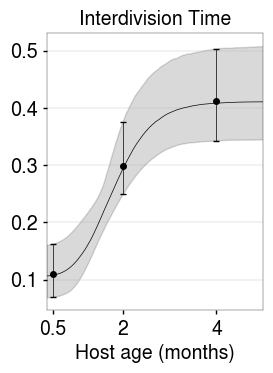

In [81]:
# Build b_t earlier as 2D array: (time_points, posterior_samples)
b_t = np.asarray(b_t, dtype=float)

# Only valid where division rate is positive
valid = np.isfinite(b_t) & (b_t > 0)

interdivision_time = np.full_like(b_t, np.nan, dtype=float)
interdivision_time[valid] = 1.0 / b_t[valid]

# selected points for 0.5, 2, 4 months
day_ticks = np.array([0.5, 2, 4]) * 30
idx = np.array([np.argmin(np.abs(t_ev - tp)) for tp in day_ticks])
interdivision_time1 = interdivision_time[idx, :]

def plot_with_error_bars_interdiv(data, x_values, color, ax):
    mean_data = np.nanmean(data, axis=1)
    lower_ci = np.nanpercentile(data, 2.5, axis=1)
    upper_ci = np.nanpercentile(data, 97.5, axis=1)

    ax.errorbar(
        x_values,
        mean_data,
        yerr=[mean_data - lower_ci, upper_ci - mean_data],
        fmt='o',
        color=color,
        capsize=2,
        markersize=4,
        elinewidth=0.5,
        linestyle='none'
    )

fig, ax = plt.subplots(1, 1, figsize=(3, 4))
plot_with_error_bars_interdiv(interdivision_time1, day_ticks, 'black', ax)

# continuous curve: keep only valid rows
continuous_valid = np.any(np.isfinite(interdivision_time), axis=1)
mean_curve = np.nanmedian(interdivision_time[continuous_valid], axis=1)
lower_curve = np.nanpercentile(interdivision_time[continuous_valid], 2.5, axis=1)
upper_curve = np.nanpercentile(interdivision_time[continuous_valid], 97.5, axis=1)

ax.plot(t_ev[continuous_valid], mean_curve, color='black', linewidth=0.5)
ax.fill_between(t_ev[continuous_valid], lower_curve, upper_curve, alpha=0.15, color='black')

ax.set_xlim(11, 150)
ax.set_xticks(day_ticks)
ax.set_xticklabels([0.5, 2, 4], fontsize=14)
ax.set_xlabel('Host age (months)', fontsize=14)
ax.set_title('Interdivision Time', fontsize=14)

for spine in ax.spines.values():
    spine.set_linewidth(0.25)

ax.tick_params(axis="both", which="major", length=3, width=1)
ax.tick_params(axis="both", which="minor", length=2, width=0.5)
ax.yaxis.grid(True, linestyle='-', linewidth=0.25, alpha=0.9)

plt.tight_layout()
plt.savefig('Ontogeny_Interdivision_Time.pdf', dpi=300)

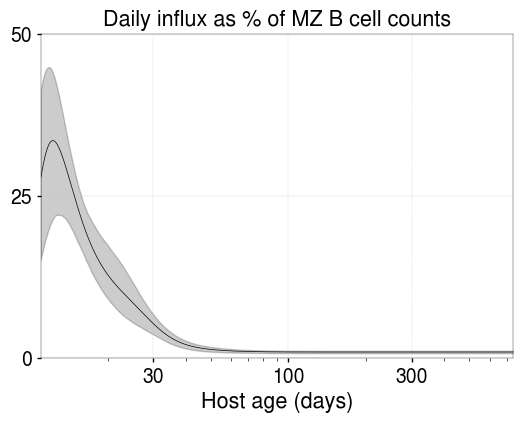

Daily influx as % of MZ B cell counts at specific host ages (days):
Host age 15 days: Mean daily influx as % of MZ B cell counts = 24.43%
Host age 30 days: Mean daily influx as % of MZ B cell counts = 5.36%
Host age 45 days: Mean daily influx as % of MZ B cell counts = 1.64%
Host age 60 days: Mean daily influx as % of MZ B cell counts = 1.16%
Host age 90 days: Mean daily influx as % of MZ B cell counts = 1.00%
Host age 120 days: Mean daily influx as % of MZ B cell counts = 0.98%
Host age 150 days: Mean daily influx as % of MZ B cell counts = 0.98%


In [79]:
# Plotting daily influx as a fraction of MZ B cell counts


def ode_function(t, y, phi, phi0, r, b, d, k):
    M_val = y[0]
    # dMdt = phi * P(t) + b_time(rho, M_val, M_stable, K) * M_val - delta*M_val
    dMdt = q(t, phi, phi0, r) * P2(t)+ b_m(M_val, b, k) * M_val - d*M_val
    
    return [dMdt]

# Use posterior means (or derive S from posterior samples)
phi = unified_T2.phi
phi0 = unified_T2.phi0
r = unified_T2.r
b = unified_T2.b
d = unified_T2.d
k = unified_T2.K



M0 = [12058.0]
# use a reasonable time step (very small dt can make solver struggle); 0.1 matches other cells
t_ev = np.arange(11.0, 750.0, 0.1)
sol = np.zeros((len(b), len(t_ev)))
for i in range(len(b)):
    # Solve once over the full interval (vectorized call) instead of calling solve_ivp in a loop
    result = solve_ivp(ode_function,
                        [t_ev[0], t_ev[-1]],
                M0,
                t_eval=t_ev,
                args=(phi[i], phi0[i], r[i], b[i], d[i], k[i]))
    sol[i, :] = result.y[0]

# Extract solution and compute influx(t)/M(t)
influx_rate = np.zeros((len(t_ev), len(b)))
for i in range(len(b)):
    M_t = sol[i, :]
    influx_rate[:, i] = ((q(t_ev, phi[i], phi0[i], r[i]) * P2(t_ev)) / M_t) * 100  # Daily influx as % of MZ B cells
   
    
# Calculate statistics
influx_rate_median = np.mean(influx_rate, axis=1)
influx_rate_lower = np.quantile(influx_rate, 0.025, axis=1)
influx_rate_upper = np.quantile(influx_rate, 0.975, axis=1)
fig, axes = plt.subplots(1, 1, figsize=(5.5, 4.5))
axes.plot(t_ev, influx_rate_median, color='black', linewidth=0.5)
axes.fill_between(t_ev, influx_rate_lower, influx_rate_upper, alpha=0.2, color='black')
axes.set_ylim(0, 50)
plt.yticks([0, 25, 50], [0, 25, 50])
axes.set_xlim(11, 740)
plt.xscale('log')
# plt.yscale('log')
plt.xticks([ 30, 100, 300], [ 30, 100, 300])
# axes.set_ylabel('Daily influx / MZ B cell count')   
plt.title('Daily influx as % of MZ B cell counts')            
axes.set_xlabel('Host age (days)')
ax = plt.gca()
# Axis border width
ax.spines['top'].set_linewidth(0.25)
ax.spines['right'].set_linewidth(0.25)
ax.spines['bottom'].set_linewidth(0.25)
ax.spines['left'].set_linewidth(0.25)
ax.tick_params(axis="both", labelsize=14)
# tick mark size and thickness
ax.tick_params(axis="both", which="major", length=3, width=1)
ax.tick_params(axis="both", which="minor", length=2, width=0.5)
axes.grid(True, axis="x", ls="-.", color='silver', linewidth=0.25)
axes.grid(True, axis="y", ls="--", color='silver', linewidth=0.25)
plt.tight_layout()          
plt.savefig('Ontogeny_Daily_Influx_Fraction.pdf', dpi=300)
plt.show()  


print('Daily influx as % of MZ B cell counts at specific host ages (days):')
for tp in time_points_days:
    idx = np.argmin(np.abs(t_ev - tp))
    mean_influx_fraction = np.mean(influx_rate[idx, :])
    print(f'Host age {tp} days: Mean daily influx as % of MZ B cell counts = {mean_influx_fraction:.2f}%')


In [82]:
# Plotting self-renewal as a fraction of MZ B cell counts


def ode_function(t, y, phi, phi0, r, b, d, k):
    M_val = y[0]
    # dMdt = phi * P(t) + b_time(rho, M_val, M_stable, K) * M_val - delta*M_val
    dMdt = q(t, phi, phi0, r) * P2(t)+ b_m(M_val, b, k) * M_val - d*M_val
    
    return [dMdt]

# Use posterior means (or derive S from posterior samples)
phi = unified_T2.phi
phi0 = unified_T2.phi0
r = unified_T2.r
b = unified_T2.b
d = unified_T2.d
k = unified_T2.K



M0 = [12058.0]
# use a reasonable time step (very small dt can make solver struggle); 0.1 matches other cells
t_ev = np.arange(11.0, 750.0, 0.1)
sol = np.zeros((len(b), len(t_ev)))
for i in range(len(b)):
    # Solve once over the full interval (vectorized call) instead of calling solve_ivp in a loop
    result = solve_ivp(ode_function,
                        [t_ev[0], t_ev[-1]],
                M0,
                t_eval=t_ev,
                args=(phi[i], phi0[i], r[i], b[i], d[i], k[i]))
    sol[i, :] = result.y[0]

# Extract solution and compute influx(t)/M(t)
self_renewal_rate = np.zeros((len(t_ev), len(b)))
for i in range(len(b)):
    M_t = sol[i, :]
    self_renewal_rate[:, i] = b_m(M_t, b, k) * 100  # Daily influx as % of MZ B cells
   
    
# Calculate statistics
self_renewal_rate_median = np.mean(self_renewal_rate, axis=1)
self_renewal_rate_lower = np.quantile(self_renewal_rate, 0.025, axis=1)
self_renewal_rate_upper = np.quantile(self_renewal_rate, 0.975, axis=1)
fig, axes = plt.subplots(1, 1, figsize=(5.5, 4.5))
axes.plot(t_ev, self_renewal_rate_median, color='black', linewidth=0.5)
axes.fill_between(t_ev, self_renewal_rate_lower, self_renewal_rate_upper, alpha=0.2, color='black')
axes.set_ylim(0, 50)
plt.yticks([0, 25, 50], [0, 25, 50])
axes.set_xlim(11, 740)
plt.xscale('log')
# plt.yscale('log')
plt.xticks([ 30, 100, 300], [ 30, 100, 300])
# axes.set_ylabel('Daily influx / MZ B cell count')   
plt.title('Self renewal as % of MZ B cell counts')            
axes.set_xlabel('Host age (days)')
ax = plt.gca()
# Axis border width
ax.spines['top'].set_linewidth(0.25)
ax.spines['right'].set_linewidth(0.25)
ax.spines['bottom'].set_linewidth(0.25)
ax.spines['left'].set_linewidth(0.25)
ax.tick_params(axis="both", labelsize=14)
# tick mark size and thickness
ax.tick_params(axis="both", which="major", length=3, width=1)
ax.tick_params(axis="both", which="minor", length=2, width=0.5)
axes.grid(True, axis="x", ls="-.", color='silver', linewidth=0.25)
axes.grid(True, axis="y", ls="--", color='silver', linewidth=0.25)
plt.tight_layout()          
plt.savefig('Ontogeny_Self_renewal_Fraction.pdf', dpi=300)
plt.show()  


print('Self renewal as % of MZ B cell counts at specific host ages (days):')
for tp in time_points_days:
    idx = np.argmin(np.abs(t_ev - tp))
    mean_division_fraction = np.mean(self_renewal_rate[idx, :])
    print(f'Host age {tp} days: Mean daily influx as % of MZ B cell counts = {mean_division_fraction:.2f}%')



ValueError: operands could not be broadcast together with shapes (7390,) (5000,) 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


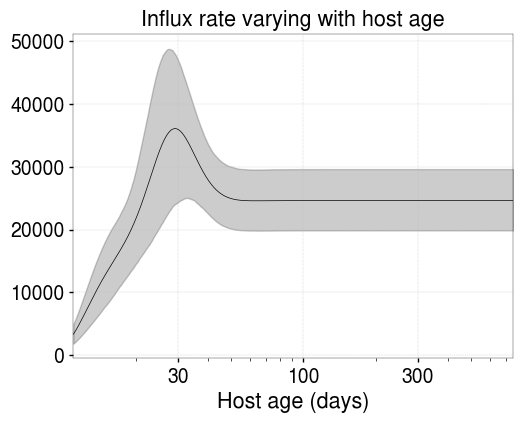

In [ ]:
#Plot totalinflux 
t_ev = np.arange(11.0, 750.0, 0.1)
plt.figure(figsize=(5.5, 4.5))
influx_values = np.zeros((len(t_ev), len(r)))
for i in range(len(r)):
    influx_values[:, i] = q(t_ev, phi[i], phi0[i], r[i]) * P2(t_ev)

# total_influx = SHM_df_T2.phi 
influx_median = np.mean(influx_values, axis=1)
influx_lower = np.quantile(influx_values, 0.025, axis=1)
influx_upper = np.quantile(influx_values, 0.975, axis=1)
plt.plot(t_ev, influx_median, color='black', linewidth=0.5)
plt.fill_between(t_ev, influx_lower, influx_upper, alpha=0.2, color='black')
# plt.axhline(y=np.median(total_influx), color='orange', label='Influx rate derived \n from chimera data', linewidth=0.25)
# plt.axhspan(np.quantile(total_influx, 0.025), np.quantile(total_influx, 0.975), color='orange', alpha=0.15)
# plt.yscale('log')
plt.xscale('log')
# plt.ylim(0, 0.032)
# plt.yticks([0, 0.01, 0.02, 0.03], ['0', '0.01', '0.02', '0.03'])
plt.xlim(11, 750)
plt.xticks([ 30, 100, 300], [ 30, 100, 300])
plt.title('Influx rate varying with host age')
plt.xlabel('Host age (days)')
ax = plt.gca()
# Axis border width 
ax.spines['top'].set_linewidth(0.25)
ax.spines['right'].set_linewidth(0.25)
ax.spines['bottom'].set_linewidth(0.25)  
ax.spines['left'].set_linewidth(0.25)
ax.tick_params(axis="both", labelsize=14)
# tick mark size and thickness
ax.tick_params(axis="both", which="major", length=3, width=1)
ax.tick_params(axis="both", which="minor", length=2, width=0.5)
ax.grid(True, axis="x", ls="-.", color='silver', linewidth=0.25)
ax.grid(True, axis="y", ls="--", color='silver', linewidth=0.25)
plt.legend(fontsize='x-small', frameon=False)
plt.tight_layout()
# plt.savefig('Influx_rate.pdf', dpi=300)
plt.show()  

#print average total influx and upper and lower 95th percentiles at t=11 and t=750
# print('Total Influx at t=11:', np.mean(influx_values[t_ev == 11]))
# print('Upper 95th Percentile at t=11:', np.quantile(influx_values[t_ev == 11], 0.975))
# print('Lower 95th Percentile at t=11:', np.quantile(influx_values[t_ev == 11], 0.025))






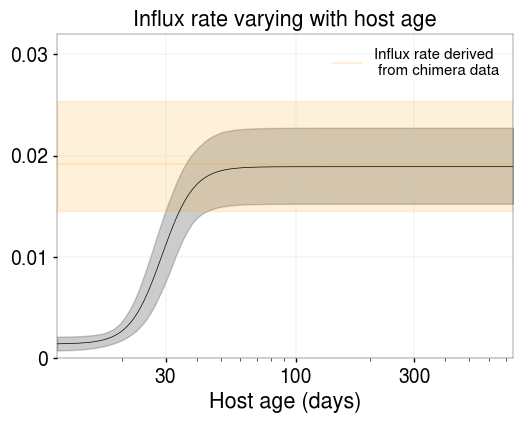

In [ ]:
#Plot influx rate
t_ev = np.arange(11.0, 750.0, 0.1)
plt.figure(figsize=(5.5, 4.5))
influx_values = np.zeros((len(t_ev), len(r)))
for i in range(len(r)):
    influx_values[:, i] = q(t_ev, phi[i], phi0[i], r[i]) 

total_influx = SHM_df_T2.phi 
influx_median = np.mean(influx_values, axis=1)
influx_lower = np.quantile(influx_values, 0.025, axis=1)
influx_upper = np.quantile(influx_values, 0.975, axis=1)
plt.plot(t_ev, influx_median, color='black', linewidth=0.5)
plt.fill_between(t_ev, influx_lower, influx_upper, alpha=0.2, color='black')
plt.axhline(y=np.median(total_influx), color='orange', label='Influx rate derived \n from chimera data', linewidth=0.25)
plt.axhspan(np.quantile(total_influx, 0.025), np.quantile(total_influx, 0.975), color='orange', alpha=0.15)
# plt.yscale('log')
plt.xscale('log')
plt.ylim(0, 0.032)
plt.yticks([0, 0.01, 0.02, 0.03], ['0', '0.01', '0.02', '0.03'])
plt.xlim(11, 750)
plt.xticks([ 30, 100, 300], [ 30, 100, 300])
plt.title('Influx rate varying with host age')
plt.xlabel('Host age (days)')
ax = plt.gca()
# Axis border width 
ax.spines['top'].set_linewidth(0.25)
ax.spines['right'].set_linewidth(0.25)
ax.spines['bottom'].set_linewidth(0.25)  
ax.spines['left'].set_linewidth(0.25)
ax.tick_params(axis="both", labelsize=14)
# tick mark size and thickness
ax.tick_params(axis="both", which="major", length=3, width=1)
ax.tick_params(axis="both", which="minor", length=2, width=0.5)
ax.grid(True, axis="x", ls="-.", color='silver', linewidth=0.25)
ax.grid(True, axis="y", ls="--", color='silver', linewidth=0.25)
plt.legend(fontsize='x-small', frameon=False)
plt.tight_layout()
plt.savefig('Influx_rate.pdf', dpi=300)
plt.show()  


In [ ]:
phi_SHM = SHM_df_T2.stan_variable('phi')
rho_SHM = SHM_df_T2.stan_variable('rho')
M_stable_SHM = SHM_df_T2.stan_variable('MZ_counts_pred1')

# delta_T1 = ((phi_samples * 1298783) / M_stable_samples[:,0] ) + rho_samples
delta_SHM = ((phi_SHM * 1308516) / M_stable_SHM[:,0] ) + rho_SHM

phi_SHM_T1 = SHM_df_T1.stan_variable('phi')
rho_SHM_T1 = SHM_df_T1.stan_variable('rho')
M_stable_SHM_T1 = SHM_df_T1.stan_variable('MZ_counts_pred1')

# delta_T1 = ((phi_samples * 1298783) / M_stable_samples[:,0] ) + rho_samples
delta_SHM_T1 = ((phi_SHM_T1 * 1308516) / M_stable_SHM_T1[:,0] ) + rho_SHM_T1

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


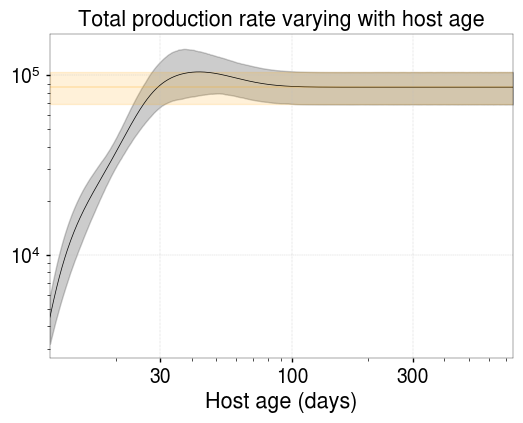

In [ ]:
#Plot total production rate (influx + division) 
t_ev = np.arange(11.0, 750.0, 0.1)
plt.figure(figsize=(5.5, 4.5))
total_production = np.zeros((len(t_ev), len(r)))
for i in range(len(r)):
    M_t = sol[i, :]
    total_production[:, i] = (q(t_ev, phi[i], phi0[i], r[i]) * P2(t_ev)) + (b_m(M_t, b[i], k[i]) * M_t)     
total_production_median = np.mean(total_production, axis=1)
total_production_lower = np.quantile(total_production, 0.025, axis=1)
total_production_upper = np.quantile(total_production, 0.975, axis=1)
plt.plot(t_ev, total_production_median, color='black', linewidth=0.5)
plt.fill_between(t_ev, total_production_lower, total_production_upper, alpha=0.2, color='black')
# delta_chimera = delta_SHM * M_stable_SHM[:,0]
delta_chimera = d* M_t_max
plt.axhline(y=np.median(delta_chimera), color='orange', linewidth=0.25)
plt.axhspan(np.quantile(delta_chimera, 0.025), np.quantile(delta_chimera, 0.975), color='orange', alpha=0.15)
plt.yscale('log')
plt.xscale('log')
# plt.ylim(0, 0.05)
# plt.yticks([0, 0.01, 0.02, 0.03, 0.04, 0.05], ['0', '0.01', '0.02', '0.03', '0.04', '0.05'])        
plt.xlim(11, 750)
# plt.ylim(3*1e3, 3*1e5)
plt.xticks([ 30, 100, 300], [ 30, 100, 300])
plt.title('Total production rate varying with host age')
plt.xlabel('Host age (days)')
# y axis ticks as 10^4, 10^5, 10^6, 10^7
# plt.yticks([1e3, 1e4, 1e5, 1e6])

ax = plt.gca()
# Axis border width 
ax.spines['top'].set_linewidth(0.25)
ax.spines['right'].set_linewidth(0.25)
ax.spines['bottom'].set_linewidth(0.25)
ax.spines['left'].set_linewidth(0.25)
ax.tick_params(axis="both", labelsize=14)
# tick mark size and thickness
ax.tick_params(axis="both", which="major", length=3, width=1)
ax.tick_params(axis="both", which="minor", length=2, width=0.5)
ax.grid(True, axis="x", ls="-.", color='silver', linewidth=0.25)
ax.grid(True, axis="y", ls="--", color='silver', linewidth=0.25)
plt.legend(fontsize='x-small', frameon=False)
plt.tight_layout()
plt.savefig('Total_Production.pdf', dpi=300)
plt.show()      

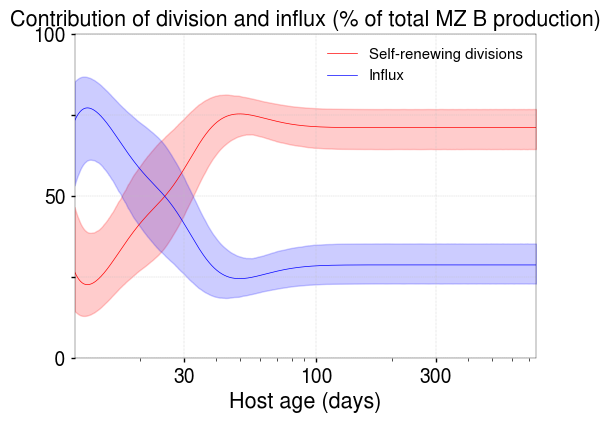

Self-renewal and influx as % of total production at specific host ages (days):
Host age 15 days: Mean self-renewal as % of total production = 28.10%, Mean influx as % of total production = 71.90%
Host age 30 days: Mean self-renewal as % of total production = 58.55%, Mean influx as % of total production = 41.45%
Host age 45 days: Mean self-renewal as % of total production = 74.89%, Mean influx as % of total production = 25.11%
Host age 60 days: Mean self-renewal as % of total production = 74.40%, Mean influx as % of total production = 25.60%
Host age 90 days: Mean self-renewal as % of total production = 71.72%, Mean influx as % of total production = 28.28%
Host age 120 days: Mean self-renewal as % of total production = 71.24%, Mean influx as % of total production = 28.76%
Host age 150 days: Mean self-renewal as % of total production = 71.17%, Mean influx as % of total production = 28.83%


In [ ]:
# self-renewal and influx as a fraction of total production
t_ev = np.arange(11.0, 750.0, 0.1)
plt.figure(figsize=(5.5, 4.5))
self_renewal_fraction = np.zeros((len(t_ev), len(r)))
influx_fraction = np.zeros((len(t_ev), len(r)))

for i in range(len(r)): 
    M_t = sol[i, :]
    self_renewal_fraction[:, i] = ((b_m(M_t, b[i], k[i]) * M_t) / ((q(t_ev, phi[i], phi0[i], r[i]) * P2(t_ev)) + (b_m(M_t, b[i], k[i]) * M_t))) * 100
    influx_fraction[:, i] = ((q(t_ev, phi[i], phi0[i], r[i]) * P2(t_ev)) / ((q(t_ev, phi[i], phi0[i], r[i]) * P2(t_ev)) + (b_m(M_t, b[i], k[i]) * M_t))) * 100
self_renewal_fraction_median = np.mean(self_renewal_fraction, axis=1)
self_renewal_fraction_lower = np.quantile(self_renewal_fraction, 0.025, axis=1)
self_renewal_fraction_upper = np.quantile(self_renewal_fraction, 0.975, axis=1)
influx_fraction_median = np.mean(influx_fraction, axis=1)
influx_fraction_lower = np.quantile(influx_fraction, 0.025, axis=1)
influx_fraction_upper = np.quantile(influx_fraction, 0.975, axis=1)
plt.plot(t_ev, self_renewal_fraction_median, color='red', linewidth=0.5, label = 'Self-renewing divisions')
plt.fill_between(t_ev,  self_renewal_fraction_lower, self_renewal_fraction_upper, alpha=0.2, color='red')
plt.plot(t_ev, influx_fraction_median, color='blue', linewidth=0.5, label='Influx')
plt.fill_between(t_ev, influx_fraction_lower, influx_fraction_upper, alpha=0.2, color='blue')
# self_renewal_fraction_chimera = (b_m(M_t, np.median(b), np.median(k)) * M_t) / (SHM_df_T2.phi*1308516 + (b_m(M_t, np.median(b), np.median(k)) * M_t)) * 100
# plt.axhline(y=np.median(self_renewal_fraction_chimera), color='orange', label='Self-renewal fraction derived \n from chimera data', linewidth=0.25)
# plt.axhspan(np.quantile           (self_renewal_fraction_chimera, 0.025), np.quantile(self_renewal_fraction_chimera, 0.975), color='orange', alpha=0.15)
plt.ylim(0, 100)
plt.yticks([0, 25, 50, 75, 100], [' 0', '', '50', '', '100'])
plt.xlim(11, 750)
plt.xscale('log')       
plt.xticks([ 30, 100, 300], [ 30, 100, 300])
plt.title('Contribution of division and influx (% of total MZ B production)')
plt.xlabel('Host age (days)')
ax = plt.gca()
# Axis border width     
ax.spines['top'].set_linewidth(0.25)
ax.spines['right'].set_linewidth(0.25)
ax.spines['bottom'].set_linewidth(0.25)
ax.spines['left'].set_linewidth(0.25)
ax.tick_params(axis="both", labelsize=14)
# tick mark size and thickness
ax.tick_params(axis="both", which="major", length=3, width=1)
ax.tick_params(axis="both", which="minor", length=2, width=0.5)
ax.grid(True, axis="x", ls="-.", color='silver', linewidth=0.25)
ax.grid(True, axis="y", ls="--", color='silver', linewidth  =0.25)
plt.legend(fontsize='x-small', frameon=False)
plt.tight_layout()
plt.savefig('Self_Renewal_Fraction.pdf', dpi=300)
plt.show()  
print('Self-renewal and influx as % of total production at specific host ages (days):')
for tp in time_points_days:
    idx = np.argmin(np.abs(t_ev - tp))
    mean_self_renewal_fraction = np.mean(self_renewal_fraction[idx, :])
    mean_influx_fraction = np.mean(influx_fraction[idx, :])
    print(f'Host age {tp} days: Mean self-renewal as % of total production = {mean_self_renewal_fraction:.2f}%, Mean influx as % of total production = {mean_influx_fraction:.2f}%')

[325863.29122923 472026.51172493 408890.12425215 ... 426866.1104914
 387245.58793696 393400.89565759]


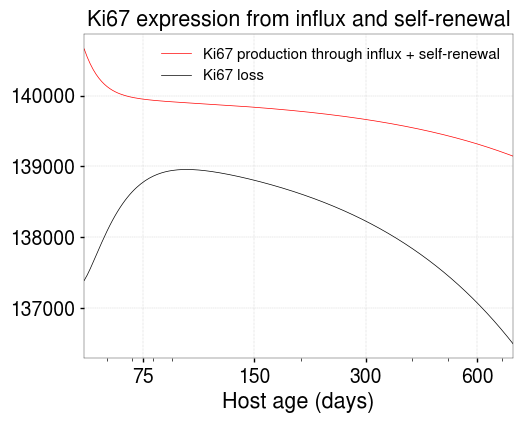

Ki67 expression from influx and self-renewal at specific host ages (days):
Host age 15 days: Mean Ki67 from influx = 0.1826, Mean Ki67 from self-renewal = 0.8174
Host age 30 days: Mean Ki67 from influx = 0.1826, Mean Ki67 from self-renewal = 0.8174
Host age 45 days: Mean Ki67 from influx = 0.1826, Mean Ki67 from self-renewal = 0.8174
Host age 60 days: Mean Ki67 from influx = 0.1799, Mean Ki67 from self-renewal = 0.8201
Host age 90 days: Mean Ki67 from influx = 0.1791, Mean Ki67 from self-renewal = 0.8209
Host age 120 days: Mean Ki67 from influx = 0.1789, Mean Ki67 from self-renewal = 0.8211
Host age 150 days: Mean Ki67 from influx = 0.1786, Mean Ki67 from self-renewal = 0.8214



In [ ]:
#Plot Ki67 expression that contributes to MZ B compartment from Ki67 high cells recruited from the periphery and from self-renewal
t_ev = np.arange(52.0, 750.0, 1)
plt.figure(figsize=(5.5, 4.5))
total_ki67 = np.zeros((len(t_ev), len(r)))
total_Ki67_MZB = np.zeros((len(t_ev), len(r)))
ki67_from_influx = np.zeros((len(t_ev), len(r)))
ki67_from_self_renewal = np.zeros((len(t_ev), len(r)))

def eps_donor2(time, m=-3.79e-5, c=0.99, t0=40):
    time = np.asarray(time)
    return np.where(time < t0, 0.0, m * (time - t0) + c)

def eps_host2(time, m=-1.7e-4, c=0.98, t0=40):
    time = np.asarray(time)
    return np.where(time < t0, 0.0, m * (time - t0) + c)

def chi_source2(time, chi_est=0.85, nu=0.1, t0=10):
    time = np.asarray(time)
    return np.where(time < t0, 0.0, chi_est * (1 - np.exp(-nu * (time - t0))))

weights = np.array([1, 2, 1, 2])
result = (
    SHM_df_T2.k_hat_pred1
    .reshape(SHM_df_T2.k_hat_pred1.shape[0], 698, 4)
    * weights
).sum(axis=2)
# print(result)

weight = np.array([1, 0, 1, 0])
Ki67_MZ= (
    SHM_df_T2.k_hat_pred1
    .reshape(SHM_df_T2.k_hat_pred1.shape[0], 698, 4)
    * weight
).sum(axis=2)

print(np.mean(Ki67_MZ, axis=1))
delta = ((SHM_df_T2.phi* 1308516) / SHM_df_T2.MZ_counts_pred1[:,0]) + SHM_df_T2.rho


for i in range(len(r)):
        influx = SHM_df_T2.phi[i] * P2(t_ev) * ((eps_donor2(t_ev) * chi_source2(t_ev)) + (eps_host2(t_ev) * (1 - chi_source2(t_ev))))
        self_renewal = SHM_df_T2.rho[i] * result[i, :]
        total_Ki67_MZB[:, i] = ((1/3.5) + delta[i]) * Ki67_MZ[i,:]
        total_ki67[:, i] = influx + self_renewal
        ki67_from_influx[:, i] = influx / total_ki67[:, i]
        ki67_from_self_renewal[:, i] = self_renewal / total_ki67[:, i]
total_ki67_median = np.mean(total_ki67, axis=1)
total_ki67_lower = np.quantile(total_ki67, 0.025, axis=1)
total_ki67_upper = np.quantile(total_ki67, 0.975, axis=1)

total_Ki67_MZB_pool = np.mean(total_Ki67_MZB, axis=1)

ki67_from_influx_median = np.mean(ki67_from_influx, axis=1)
ki67_from_influx_lower = np.quantile(ki67_from_influx, 0.025, axis=1)
ki67_from_influx_upper = np.quantile(ki67_from_influx, 0.975, axis=1)

ki67_from_self_renewal_median = np.mean(ki67_from_self_renewal, axis=1)
ki67_from_self_renewal_lower = np.quantile(ki67_from_self_renewal, 0.025, axis=1)
ki67_from_self_renewal_upper = np.quantile(ki67_from_self_renewal, 0.975, axis=1)
# plt.plot(t_ev, ki67_from_influx_median, color='black', linewidth=0.5, label='Ki67 from influx')
plt.plot(t_ev, total_ki67_median, color='red', linewidth=0.5, label='Ki67 production through influx + self-renewal')
plt.plot(t_ev, total_Ki67_MZB_pool, color='black', linewidth=0.5, label='Ki67 loss')

# plt.fill_between(t_ev, ki67_from_influx_lower, ki67_from_influx_upper, alpha=0.2, color='black')
# plt.plot(t_ev, ki67_from_self_renewal_median, color='blue', linewidth=0.5, label='Ki67 from self-renewal')
# plt.fill_between(t_ev, ki67_from_self_renewal_lower, ki67_from_self_renewal_upper, alpha=0.2, color='blue')
# plt.ylim(0, 0.03)
# plt.yticks([0, 0.01, 0.02, 0.03], ['0', '0.01', '0.02', '0.03'])
plt.xlim(52, 750)
plt.xscale('log')   
plt.xticks([75, 150, 300, 600], [ 75, 150, 300, 600])
plt.title('Ki67 expression from influx and self-renewal')
plt.xlabel('Host age (days)')
ax = plt.gca()
# Axis border width
ax.spines['top'].set_linewidth(0.25)
ax.spines['right'].set_linewidth(0.25)
ax.spines['bottom'].set_linewidth(0.25)
ax.spines['left'].set_linewidth(0.25)
ax.tick_params(axis="both", labelsize=14)
# tick mark size and thickness
ax.tick_params(axis="both", which="major", length=3, width=1)
ax.tick_params(axis="both", which="minor", length=2, width=0.5)
ax.grid(True, axis="x", ls="-.", color='silver', linewidth=0.25)
ax.grid(True, axis="y", ls="--", color='silver', linewidth=0.25)
plt.legend(fontsize='x-small', frameon=False)
plt.tight_layout()
plt.savefig('Ki67_Influx_SelfRenewal.pdf', dpi=300)
plt.show()
print('Ki67 expression from influx and self-renewal at specific host ages (days):')
for tp in time_points_days:
    idx = np.argmin(np.abs(t_ev - tp))
    mean_ki67_influx = np.mean(ki67_from_influx[idx, :])
    mean_ki67_self_renewal = np.mean(ki67_from_self_renewal[idx, :])
    print(f'Host age {tp} days: Mean Ki67 from influx = {mean_ki67_influx:.4f}, Mean Ki67 from self-renewal = {mean_ki67_self_renewal:.4f}')    
print()


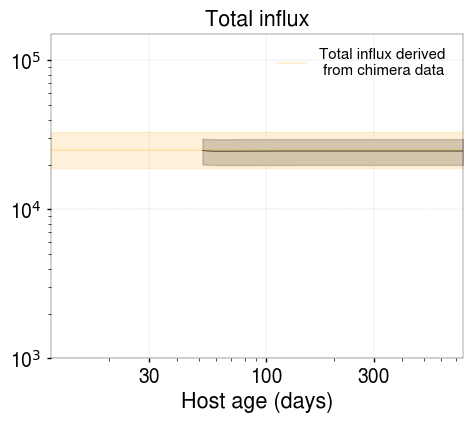

In [ ]:
# Plot S(t.r) over time

plt.figure(figsize=(5, 4.5))
S_values = np.zeros((len(t_ev), len(r)))
for i in range(len(r)):
    S_values[:, i] = q(t_ev, phi[i], phi0[i], r[i]) * P2(t_ev)

total_influx = SHM_df_T2.phi * 1308516
S_median = np.mean(S_values, axis=1)
S_lower = np.quantile(S_values, 0.025, axis=1)
S_upper = np.quantile(S_values, 0.975, axis=1)
plt.plot(t_ev, S_median, color='black', linewidth=0.5)
plt.fill_between(t_ev, S_lower, S_upper, alpha=0.2, color='black')
plt.axhline(y=np.median(total_influx), color='orange', label='Total influx derived \n from chimera data', linewidth=0.25)
plt.axhspan(np.quantile(total_influx, 0.025), np.quantile(total_influx, 0.975), color='orange', alpha=0.15)
plt.yscale('log')
plt.xscale('log')
plt.ylim(1e3, 1.5e5)
plt.yticks([1e3,  1e4, 1e5], ['10$^3$', '10$^4$', '10$^5$'])
plt.xlim(11, 750)
plt.xticks([ 30, 100, 300], [ 30, 100, 300])
plt.title('Total influx')
plt.xlabel('Host age (days)')
ax = plt.gca()
# Axis border width 
ax.spines['top'].set_linewidth(0.25)
ax.spines['right'].set_linewidth(0.25)
ax.spines['bottom'].set_linewidth(0.25)  
ax.spines['left'].set_linewidth(0.25)
ax.tick_params(axis="both", labelsize=14)
# tick mark size and thickness
ax.tick_params(axis="both", which="major", length=3, width=1)
ax.tick_params(axis="both", which="minor", length=2, width=0.5)
ax.grid(True, axis="x", ls="-.", color='silver', linewidth=0.25)
ax.grid(True, axis="y", ls="--", color='silver', linewidth=0.25)
plt.legend(fontsize='x-small', frameon=False)
plt.tight_layout()
plt.savefig('Total_influx.pdf', dpi=300)
plt.show()  


In [ ]:
def posterior_summary(samples, name=""):
    """Calculate mean and 95% credible interval for posterior samples."""
    mean = np.mean(samples, axis=0)
    lb = np.quantile(samples, 0.025, axis=0)
    ub = np.quantile(samples, 0.975, axis=0)
    if name:
        print(f"{name}: Mean={mean:.6f}, 95% CI=[{lb:.6f}, {ub:.6f}]")
    return mean, lb, ub

# Example usage:
phi_mean, phi_lb, phi_ub = posterior_summary(phi_SHM, "phi")
rho_mean, rho_lb, rho_ub = posterior_summary(rho_SHM, "rho")
delta_mean, delta_lb, delta_ub = posterior_summary(delta_SHM, "delta")

phi_mean_T1, phi_lb_T1, phi_ub_T1 = posterior_summary(phi_SHM_T1, "phi_T1")
rho_mean_T1, rho_lb_T1, rho_ub_T1 = posterior_summary(rho_SHM_T1, "rho_T1")
delta_mean_T1, delta_lb_T1, delta_ub_T1 = posterior_summary(delta_SHM_T1, "delta_T1")


phi: Mean=0.019345, 95% CI=[0.014524, 0.025371]
rho: Mean=0.025330, 95% CI=[0.018958, 0.031989]
delta: Mean=0.035495, 95% CI=[0.029007, 0.042275]
phi_T1: Mean=0.018852, 95% CI=[0.014308, 0.024347]
rho_T1: Mean=0.025343, 95% CI=[0.018934, 0.032258]
delta_T1: Mean=0.035281, 95% CI=[0.028712, 0.042163]


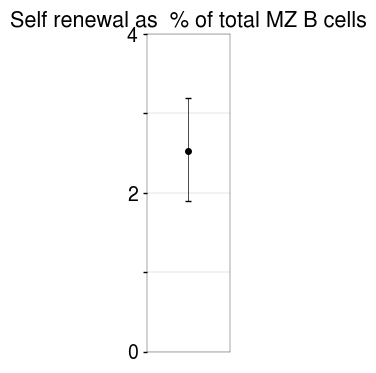

Self-renewal as % of total MZ B cells (days): 2.532994216
Upper bound: 3.19891825
Lower bound: 1.89582


In [ ]:
#Plotting interdivision, residence, influx as a % of MZ B cells, and self-renewal as a % of total MZ B cells.

self_renewal = SHM_df_T2.rho * 100

def plot_with_error_bars_res(data, color, ax):
    mean_data = np.mean(data, axis=0)
    lower_ci = np.quantile(data, 0.025, axis=0)
    upper_ci = np.quantile(data, 0.975, axis=0)
    
    # Ensure mean_rho_inv, lower_ci, and upper_ci are arrays
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    x_values = np.arange(len(mean_data))
    
    ax.errorbar(x_values, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color= color, capsize=2, markersize=4, elinewidth=0.5)
    
fig, ax = plt.subplots(1, 1, figsize=(1.5, 4))
plot_with_error_bars_res(self_renewal, 'black', ax)
ax.set_yticks([0, 1, 2, 3, 4])
ax.set_yticklabels(['0', '', '2', '', '4'], fontsize=14)
ax.set_xticklabels([])
ax.set_xticks([])
ax.set_title('Self renewal as  % of total MZ B cells')
ax = plt.gca()

# Axis border width
for spine in ax.spines.values():
    spine.set_linewidth(0.25) 
ax.tick_params(axis="both", which="major", length=3, width=1)
ax.tick_params(axis="both", which="minor", length=2, width=0.5)
# ax.set_xlabel('Turnover \n Time', fontsize=10)


ax.yaxis.grid(True, linestyle='-', linewidth=0.25, alpha=0.9)
plt.tight_layout()
plt.savefig('Adult_self_renewal_Time_parameter.pdf', dpi=300)
plt.show()
print('Self-renewal as % of total MZ B cells (days):', np.mean(self_renewal))
print('Upper bound:', np.quantile(self_renewal, 0.975))
print('Lower bound:', np.quantile(self_renewal, 0.025))

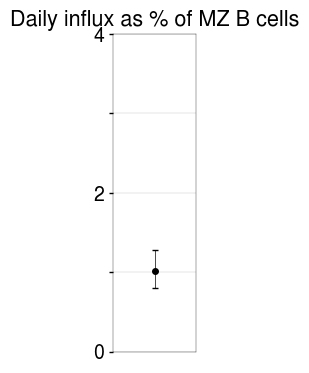

Daily influx as % of MZ B cells (days): 1.0164583241395153
Upper bound: 1.282470891348482
Lower bound: 0.7971523088436617


In [ ]:
#Plotting interdivision, residence, influx as a % of MZ B cells, and self-renewal as a % of total MZ B cells.

daily_influx = (SHM_df_T2.phi * 1308516 *100)/ SHM_df_T2.MZ_counts_pred1[:,0]

def plot_with_error_bars_res(data, color, ax):
    mean_data = np.mean(data, axis=0)
    lower_ci = np.quantile(data, 0.025, axis=0)
    upper_ci = np.quantile(data, 0.975, axis=0)
    
    # Ensure mean_rho_inv, lower_ci, and upper_ci are arrays
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    x_values = np.arange(len(mean_data))
    
    ax.errorbar(x_values, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color= color, capsize=2, markersize=4, elinewidth=0.5)
    
fig, ax = plt.subplots(1, 1, figsize=(1.5, 4))
plot_with_error_bars_res(daily_influx, 'black', ax)
ax.set_yticks([0, 1, 2, 3, 4])
ax.set_yticklabels(['0', '', '2', '', '4'], fontsize=14)
ax.set_xticklabels([])
ax.set_xticks([])
ax.set_title('Daily influx as % of MZ B cells')
ax = plt.gca()

# Axis border width
for spine in ax.spines.values():
    spine.set_linewidth(0.25) 
ax.tick_params(axis="both", which="major", length=3, width=1)
ax.tick_params(axis="both", which="minor", length=2, width=0.5)
# ax.set_xlabel('Turnover \n Time', fontsize=10)


ax.yaxis.grid(True, linestyle='-', linewidth=0.25, alpha=0.9)
plt.tight_layout()
plt.savefig('Adult_daily_influx_Time_parameter.pdf', dpi=300)
plt.show()
print('Daily influx as % of MZ B cells (days):', np.mean(daily_influx))
print('Upper bound:', np.quantile(daily_influx, 0.975))
print('Lower bound:', np.quantile(daily_influx, 0.025))

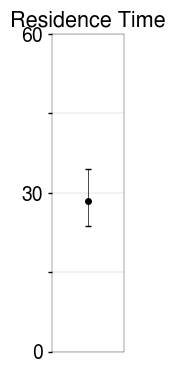

Mean residence time (days): 28.43164720447889
Upper bound: 34.47446127570005
Lower bound: 23.654446862752998


In [ ]:
#Plotting interdivision, residence, influx as a % of MZ B cells, and self-renewal as a % of total MZ B cells.
# Residence time 

residence_time = 1 / delta_SHM

def plot_with_error_bars_res(data, color, ax):
    mean_data = np.mean(data, axis=0)
    lower_ci = np.quantile(data, 0.025, axis=0)
    upper_ci = np.quantile(data, 0.975, axis=0)
    
    # Ensure mean_rho_inv, lower_ci, and upper_ci are arrays
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    x_values = np.arange(len(mean_data))
    
    ax.errorbar(x_values, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color= color, capsize=2, markersize=4, elinewidth=0.5)
    
fig, ax = plt.subplots(1, 1, figsize=(1.5, 4))
plot_with_error_bars_res(residence_time, 'black', ax)
ax.set_yticks([0, 15, 30, 45, 60])
ax.set_yticklabels(['0', '', '30', '', '60'], fontsize=14)
ax.set_xticklabels([])
ax.set_xticks([])
ax.set_title('Residence Time')
ax = plt.gca()

# Axis border width
for spine in ax.spines.values():
    spine.set_linewidth(0.25) 
ax.tick_params(axis="both", which="major", length=3, width=1)
ax.tick_params(axis="both", which="minor", length=2, width=0.5)
# ax.set_xlabel('Turnover \n Time', fontsize=10)


ax.yaxis.grid(True, linestyle='-', linewidth=0.25, alpha=0.9)
plt.tight_layout()
plt.savefig('Adult_Residence_Time_parameter.pdf', dpi=300)
plt.show()
print('Mean residence time (days):', np.mean(residence_time))
print('Upper bound:', np.quantile(residence_time, 0.975))
print('Lower bound:', np.quantile(residence_time, 0.025))

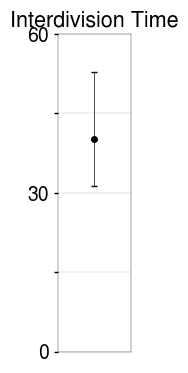

Mean interdivision time (days): 40.16734388869979
Upper bound: 52.747624234990155
Lower bound: 31.260567545274792


In [ ]:
#Plotting interdivision, residence, influx as a % of MZ B cells, and self-renewal as a % of total MZ B cells.


interdivision_time = 1 / rho_SHM

def plot_with_error_bars_res(data, color, ax):
    mean_data = np.mean(data, axis=0)
    lower_ci = np.quantile(data, 0.025, axis=0)
    upper_ci = np.quantile(data, 0.975, axis=0)
    
    # Ensure mean_rho_inv, lower_ci, and upper_ci are arrays
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    x_values = np.arange(len(mean_data))
    
    ax.errorbar(x_values, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color= color, capsize=2, markersize=4, elinewidth=0.5)
    
fig, ax = plt.subplots(1, 1, figsize=(1.5, 4))
plot_with_error_bars_res(interdivision_time, 'black', ax)
ax.set_yticks([0, 15, 30, 45, 60])
ax.set_yticklabels(['0', '', '30', '', '60'], fontsize=14)
ax.set_xticklabels([])
ax.set_xticks([])
ax.set_title('Interdivision Time')
ax = plt.gca()

# Axis border width
for spine in ax.spines.values():
    spine.set_linewidth(0.25) 
ax.tick_params(axis="both", which="major", length=3, width=1)
ax.tick_params(axis="both", which="minor", length=2, width=0.5)
# ax.set_xlabel('Turnover \n Time', fontsize=10)


ax.yaxis.grid(True, linestyle='-', linewidth=0.25, alpha=0.9)
plt.tight_layout()
plt.savefig('Adult_Interdivision_Time_parameter.pdf', dpi=300)
plt.show()
print('Mean interdivision time (days):', np.mean(interdivision_time))
print('Upper bound:', np.quantile(interdivision_time, 0.975))
print('Lower bound:', np.quantile(interdivision_time, 0.025))

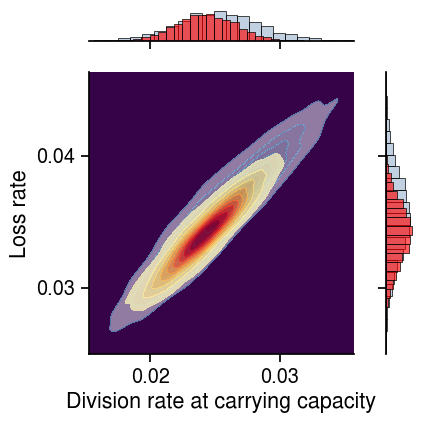

new mean(delta)   = 0.034145
new mean(rho)     = 0.024277
adult mean(delta) = 0.035495
adult mean(rho)   = 0.025330


In [ ]:
# Overlay bivariate distributions: neonatal/chimera (posterior) + adults (SHM)
# Neonatal/chimera posterior draws
new_df = pd.DataFrame({
    "delta": unified_T2.d,
    "rho": b_t_max
})

# Adult posterior draws (use delta directly if available, otherwise derive from phi and stable counts)
adult_df = pd.DataFrame({
    "delta": np.asarray(delta_SHM),
    "rho": np.asarray(rho_SHM)
})

adult_color = "#4C78A8" 
# adult_line = "#1F4E79"
# adult_cmap = sns.light_palette(adult_yellow, as_cmap=True)

# Robust limits (ignore extreme tails so contours don't look tiny)
x_all = np.concatenate([new_df["rho"].to_numpy(), adult_df["rho"].to_numpy()])
y_all = np.concatenate([new_df["delta"].to_numpy(), adult_df["delta"].to_numpy()])

x_low, x_high = np.percentile(x_all, [0.5, 99.5])
y_low, y_high = np.percentile(y_all, [0.5, 99.5])
x_pad = 0.15 * (x_high - x_low)
y_pad = 0.15 * (y_high - y_low)

xlim = (x_low - x_pad, x_high + x_pad)
ylim = (y_low - y_pad, y_high + y_pad) 
g = sns.JointGrid(height=4.5, space=0.2, xlim=xlim, ylim=ylim)

# Adult in background (fill + contour line)
sns.kdeplot(
    data=adult_df,
    x="rho", y="delta",
    cmap= 'Blues',
    fill=True,
    levels=10,
    # thresh=0.01,
    # bw_adjust=1.15,
    alpha=0.5,
    zorder=1,
    ax=g.ax_joint
)
sns.kdeplot(
    data=adult_df,
    x="rho", y="delta",
    levels=10,
    linewidths=0.5,
    alpha=0.8,
    zorder=2,
    ax=g.ax_joint
)

# Unified on top (fill + contour line)
sns.kdeplot(
    data=new_df,
    x="rho", y="delta",
    fill=True,
    cmap="YlOrRd",
    # cmap="inferno",
    
    # thresh=0.01,
    levels=10,
    # bw_adjust=1.2,
    alpha=0.75,
    zorder=3,
    ax=g.ax_joint
)
# sns.kdeplot(
#     data=new_df,
#     x="rho", y="delta",
#     color="white",
#     levels=10,
#     linewidths=0.6,
#     alpha=0.9,
#     zorder=4,
#     ax=g.ax_joint
# )

# dark background
g.ax_joint.set_facecolor("#360248" )

# Histogram-only marginals (both groups)
sns.histplot(data=adult_df, x="rho", bins=30, kde=False, color=adult_color, alpha=0.34, linewidth=0.5, ax=g.ax_marg_x)
sns.histplot(data=new_df, x="rho", bins=30, kde=False, color='red', alpha=0.62, linewidth=0.5, ax=g.ax_marg_x)

sns.histplot(data=adult_df, y="delta", bins=30, kde=False, color=adult_color, alpha=0.34, linewidth=0.5, ax=g.ax_marg_y)
sns.histplot(data=new_df, y="delta", bins=30, kde=False, color='red', alpha=0.62, linewidth=0.5, ax=g.ax_marg_y)

# Means (optional reference points)
mean_delta_adult, mean_rho_adult = adult_df["delta"].mean(), adult_df["rho"].mean()
mean_delta_new, mean_rho_new = new_df["delta"].mean(), new_df["rho"].mean()

# g.ax_joint.scatter(mean_rho_adult, mean_delta_adult, s=30, color="#4C78A8" ,zorder=4)
# g.ax_joint.scatter(mean_rho_new, mean_delta_new, s=30, color= 'red',zorder=5)
g.ax_joint.set_xlabel('Division rate at carrying capacity')
g.ax_joint.set_ylabel('Loss rate')
g.ax_joint.plot([], [], linewidth=1.8, color="#4C78A8")
g.ax_joint.plot([], [], linewidth=1.8, color='Red')


# Set exact major ticks: rho on x-axis, delta on y-axis
g.ax_joint.set_xticks([0.02, 0.03])
g.ax_joint.set_yticks([0.03, 0.04])

plt.tight_layout()
plt.savefig('bivariate_dist_rhodelta1.pdf', dpi=300)
plt.show()

print(f"new mean(delta)   = {mean_delta_new:.6f}")
print(f"new mean(rho)     = {mean_rho_new:.6f}")
print(f"adult mean(delta) = {mean_delta_adult:.6f}")
print(f"adult mean(rho)   = {mean_rho_adult:.6f}")

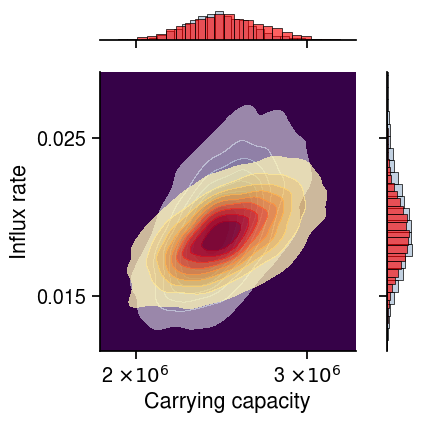

unified mean(Influx rate) = 0.02
constant mean(Influx rate) = 0.02


In [ ]:
# Plot contour distributions for total influx: Unified vs Constant birth-loss

# total_influx_shm = np.asarray(phi_SHM) * 1308516
# lambda_unified = posterior_df_T2.stan_variable("delta") - posterior_df_T2.stan_variable("rho")
# total_influx_unified = lambda_unified * posterior_df_T2.stan_variable("M_stable")

unified_influx_df = pd.DataFrame({
    "Mstable": np.asarray(M_t_max),
    "Influx_rate": np.asarray(unified_T2.stan_variable("phi")),
})

constant_influx_df = pd.DataFrame({
    "Mstable": np.asarray(SHM_df_T2.stan_variable("y0")),
    "Influx_rate": np.asarray(SHM_df_T2.stan_variable("phi")),
})

adult_color = "#4C78A8"
unified_color = "red"

# Robust limits for clean contour comparison
x_all = np.concatenate([
    unified_influx_df["Mstable"].to_numpy(),
    constant_influx_df["Mstable"].to_numpy(),
])
y_all = np.concatenate([
    unified_influx_df["Influx_rate"].to_numpy(),
    constant_influx_df["Influx_rate"].to_numpy(),
])

x_low, x_high = np.percentile(x_all, [0.5, 99.5])
y_low, y_high = np.percentile(y_all, [0.5, 99.5])
x_pad = 0.15 * (x_high - x_low)
y_pad = 0.15 * (y_high - y_low)
xlim = (x_low - x_pad, x_high + x_pad)
ylim = (y_low - y_pad, y_high + y_pad)

g = sns.JointGrid(height=4.5, space=0.2, xlim=xlim, ylim=ylim)

# Constant birth-loss in background
sns.kdeplot(
    data=constant_influx_df,
    x="Mstable", y="Influx_rate",
    cmap="Blues",
    fill=True,
    levels=10,
    alpha=0.55,
    zorder=1,
    ax=g.ax_joint
)

# Unified on top
sns.kdeplot(
    data=unified_influx_df,
    x="Mstable", y="Influx_rate",
    cmap="YlOrRd",
    fill=True,
    levels=10,
    alpha=0.75,
    zorder=2,
    ax=g.ax_joint
)

g.ax_joint.set_facecolor("#360248")

# Marginal histograms
sns.histplot(data=constant_influx_df, x="Mstable", bins=30, kde=False, color=adult_color, linewidth=0.5, alpha=0.34, ax=g.ax_marg_x)
sns.histplot(data=unified_influx_df, x="Mstable", bins=30, kde=False, color=unified_color, linewidth=0.5, alpha=0.62, ax=g.ax_marg_x)
sns.histplot(data=constant_influx_df, y="Influx_rate", bins=30, kde=False, color=adult_color, linewidth=0.5, alpha=0.34, ax=g.ax_marg_y)
sns.histplot(data=unified_influx_df, y="Influx_rate", bins=30, kde=False, color=unified_color, linewidth=0.5, alpha=0.62, ax=g.ax_marg_y)

# Means
mean_Mstable_const = constant_influx_df["Mstable"].mean()
mean_influx_const = constant_influx_df["Influx_rate"].mean()
mean_Mstable_unified = unified_influx_df["Mstable"].mean()
mean_influx_unified = unified_influx_df["Influx_rate"].mean()

# g.ax_joint.scatter(mean_Mstable_const, mean_influx_const, s=30, color=adult_color, zorder=3)
# g.ax_joint.scatter(mean_Mstable_unified, mean_influx_unified, s=30, color=unified_color, zorder=4)

g.ax_joint.set_xlabel('Carrying capacity')
g.ax_joint.set_ylabel('Influx rate')
g.ax_joint.plot([], [], linewidth=2, color=adult_color)
g.ax_joint.plot([], [], linewidth=1.8, color=unified_color)
# g.ax_joint.legend(loc="upper right", fontsize=8)

g.ax_joint.set_xticks([2e6, 3e6])
g.ax_joint.set_xticklabels(['2 $\\times 10^6$', '3 $\\times 10^6$'])
g.ax_joint.set_yticks([0.015, 0.025])
# g.ax_joint.set_yticks([2e4, 3e4])
# g.ax_joint.set_yticklabels(['2e4', '3e4'])



plt.tight_layout()
plt.savefig('bivariate_dist_influx_rate.pdf', dpi=300)
plt.show()

print(f"unified mean(Influx rate) = {mean_influx_unified:.2f}")
print(f"constant mean(Influx rate) = {mean_influx_const:.2f}")